## A notebook to learn how to code transformers by implementing them from scratch.

In [168]:
# Downloading Fashion Mnist
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from torch.nn import functional as F
import einops
from tqdm.notebook import tqdm
import torch.nn as nn

1. Download fashionMNIST dataset if not already downloaded. Split training and validation set.

60000 10000
torch.Size([1, 28, 28]) 9


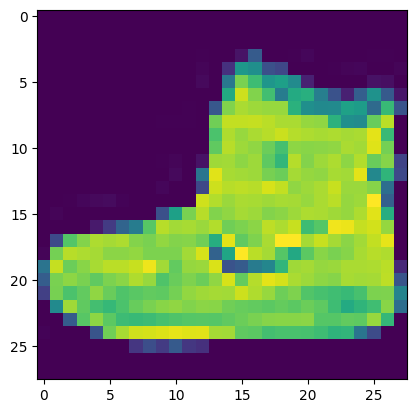

In [169]:
transform = transforms.ToTensor()

# Get data and store it in ./data folder
train_data = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

# Create dataloaders
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

# Show an example
print(len(train_data), len(test_data))
print(train_data[0][0].shape, train_data[0][1])
plt.imshow(train_data[0][0].squeeze().numpy())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


## E1. Define Patchify and Un-Patchify functions

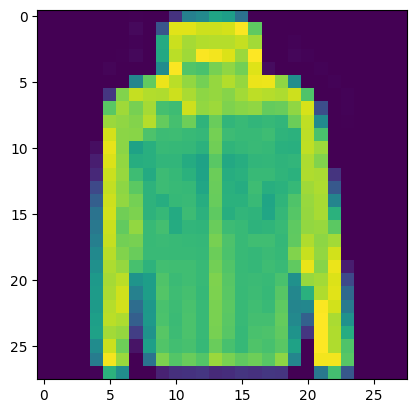

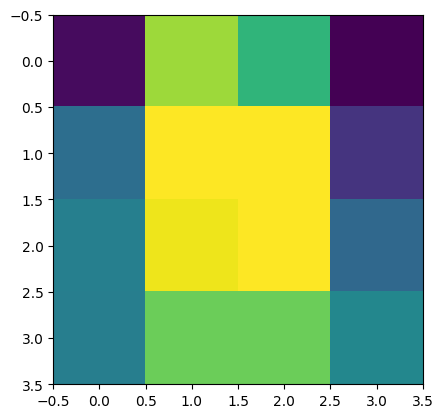

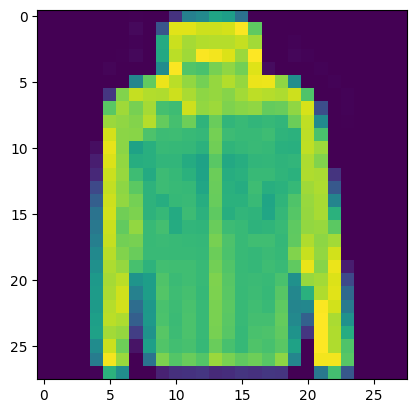

In [170]:
# --- FUNCTIONS --- 

def patchify(images: torch.Tensor, patch_size : int):
    """
    Patchifies images from (B, 1, 28, 28) to (B, 16, 49)
    
    Args:
        images: (B, C, H, W)
    """
    # Extract patches
    patches = F.unfold(images, kernel_size=patch_size, padding=0, stride=patch_size)
    # P are pixels inside a patch. G are patch grid position
    patches = einops.rearrange(patches, "... P G -> ... G P")
    return patches


def unpatchify(patches: torch.Tensor, patch_size : int, grid_size: int):
    """
    Unpatchify patches to the original image from (B, 16, 49) to (B, 1, 28, 28)
    
    Args:
        images: (B, 16, 49)
    """
    # Reshape patches. ph pw are pixels inside a patch. gh gw are patch grid position
    images = einops.rearrange(patches, "... (gh gw) (ph pw) -> ... 1 (gh ph) (gw pw)", gh=grid_size, ph=patch_size)
    
    return images

# --- TEST RUN ---

# Get image sample
images, labels = next(iter(train_loader))
patch_size = 7
grid_size = int(images[0].shape[-1] // patch_size)

# Patchify
patches = patchify(images, patch_size=patch_size)
# Unpatchify
unpatchified_images = unpatchify(patches, patch_size=patch_size, grid_size=grid_size)
# Check patchified and unpatchified images are the same
assert torch.allclose(unpatchified_images, images)   # must be EXACTLY identity

# plot actual image
plt.figure()
plt.imshow(images[0].squeeze().numpy())

# plot average of patches
plt.figure()
patch_grid = einops.rearrange(patches[0].mean(dim=-1), "(gh gw) -> gh gw", gh=grid_size)
plt.imshow(patch_grid)

# plot fully tiled patches
plt.figure()
patch_grid = einops.rearrange(patches[0], "(gh gw) (ph pw) -> (gh ph) (gw pw)", gh=grid_size, ph=patch_size)
plt.imshow(patch_grid)

    

## E2. Define Attention and a small ViT autoencoder from scratch

### E2.a. Multi-head Self-Attention

In [3]:
class MultiheadAttention(nn.Module):
    def __init__(self, dim: int, n_heads: int):
        super().__init__()
        self.head_dim = dim // n_heads
        self.n_heads = n_heads
        self.proj = nn.Linear(dim, 3 * self.head_dim * n_heads, bias=False)
        
        # The last layer that fuses multiple attention heads into a single layer
        self.to_out = nn.Linear(self.head_dim * n_heads, dim, bias=False)

        
    def forward(self, seq):
        """
        Args:
            seq (B, N, dim)
            
        Returns:
            out: (B, N, dim)
            attention: (B, n_heads, N, dim)
        """
        # project to Q, K and V
        qkv = self.proj(seq)
        # Rearrange to move head outside to perform attention calucation PER head        
        qkv = einops.rearrange(qkv, "b n (h d) -> b h n d", h = self.n_heads)
        # Divide d into 3 chunks d/3 for each query, key and value
        q, k, v = qkv.chunk(3, dim=-1)
        
        # # Rearrange to move head outside to perform attention calucation PER head
        # q, k, v = qkv.chunk(3, dim=-1)        
        # q = einops.rearrange(q, " b n (h d) -> b h n d", h = self.n_heads)
        # k = einops.rearrange(k, " b n (h d) -> b h n d", h = self.n_heads)
        # v = einops.rearrange(v, " b n (h d) -> b h n d", h = self.n_heads)
        
        # Dot product of Queries and Keys
        score_matrix = einops.einsum(q, k, "... n1 d, ... n2 d -> ... n1 n2") # contracted dimension much share same var name in einops (here it is 'd')
        
        # scale by head size
        score_matrix = score_matrix / (self.head_dim**0.5)
        
        # Applying softmax to the score matrix
        attention = torch.softmax(score_matrix, dim=-1)
        
        # Weighting attention by the value
        w = attention @ v
        
        # Move heads back to dim
        out = einops.rearrange(w, "b h n d -> b n (h d)")
        
        # Fuse multi-heads int a linear layer
        out = self.to_out(out)
        
        return out, attention


x = torch.rand((3, 10, 512))
print(x.shape)

attn = MultiheadAttention(512, 5)
print(attn(x)[0].shape)

torch.Size([3, 10, 512])
torch.Size([3, 10, 512])


### E2.b. A pre-LN Transformer block

In [4]:
class AttnBlock(nn.Module):
    def __init__(self, dim: int, n_heads: int, attn_multiple: int = 4):
        super().__init__()
        self.attention = MultiheadAttention(dim, n_heads)
        self.layer_norm1 = nn.LayerNorm(dim)
        self.layer_norm2 = nn.LayerNorm(dim)
        self.ff = nn.Sequential(
            nn.Linear(dim, attn_multiple * dim),
            nn.GELU(),
            nn.Linear(attn_multiple * dim, dim)
        )        
                
    
    def forward(self, x):
        # attending to tokens across patches with a residual
        out, _ = self.attention(self.layer_norm1(x))
        x = x + out
        
        # channel mixing per token - a "scratch space" to make sense of the tokens we attended to
        out = self.ff(self.layer_norm2(x))
        x = x + out
        
        return x
        
x = torch.rand((3, 10, 512))
print(x.shape)

attn_block = AttnBlock(512, 5)
print(attn_block(x).shape)

torch.Size([3, 10, 512])
torch.Size([3, 10, 512])


### E2.c. Assemble a ViT autoencoder

In [5]:
class ViT_Encoder(nn.Module):
    def __init__(self, dim: int, n_heads: int, z_dim: int, P: int, N: int, k: int = 2, use_pos: bool = True):
        super().__init__()
        self.use_pos = use_pos
        self.ff = nn.Sequential(nn.Linear(P, dim), nn.GELU())
                
        # Stack attention blocks
        self.attn_blocks = nn.Sequential(*[AttnBlock(dim, n_heads) for i in range(k)])
        
        # Linear layer to encode to a lower dim (not sure if we should use GELU here or not)
        self.ff2 = nn.Sequential(nn.GELU(), nn.Linear(dim, z_dim))
                        
        # Layer for positional encoding
        self.pos = nn.Parameter(torch.randn(1, N, dim) * 0.02) # N = grid_size ** 2
        
        
    def forward(self, seq):
        """
        Args:
            seq (B, N, P) P is patch_size**2 and N is number of patches rows x coloumns
            
        Returns:
            z (B, N, z_dim)
        """
        # embed sequence
        x = self.ff(seq)   
        
        # positional encoding             
        if self.use_pos:
            x = x + self.pos
        
        # Attention block
        x = self.attn_blocks(x)
        
        # project sequence to comrpessed latent vector
        z = self.ff2(x)
        return z
    
    
class ViT_Decoder(nn.Module):
    def __init__(self, dim: int, n_heads: int, z_dim: int, P: int, k: int = 2):
        super().__init__()
        
        # Linear layer to decode from a lower dim to a higher one (not sure if we should use GELU here or not)
        self.ff = nn.Sequential(nn.GELU(), nn.Linear(z_dim, dim))
        
        # Stack attention blocks
        self.attn_blocks = nn.Sequential(*[AttnBlock(dim, n_heads) for i in range(k)])
        
        # Linear layer to unembed tokens. Linear shouldn't end with an activation function since we want raw pixel values (basic ML stuff)
        self.ff2 = nn.Sequential(nn.GELU(), nn.Linear(dim, P))

    def forward(self, seq):
        """
        Args:
            seq (B, N, z_dim): latent vector encoded via ViT_Encoder
            
        Returns:
            out (B, N, P) P is patch_size**2 and N is number of patches rows x coloumns
        """
        x = self.ff(seq)
        x = self.attn_blocks(x)
        x = self.ff2(x)
        return x


class ViT_AutoEncoder(nn.Module):
    def __init__(self, dim: int, n_heads: int, z_dim: int, patch_size: int, grid_size: int, k: int = 2, use_pos=True):
        super().__init__()
        
        self.patch_size = patch_size
        self.grid_size = grid_size
        
        self.encoder = ViT_Encoder(dim, n_heads, z_dim, patch_size**2, grid_size**2, k=k, use_pos=use_pos)
        self.decoder = ViT_Decoder(dim, n_heads, z_dim, patch_size**2, k)


    def forward(self, images):
        """
        Args:
            images (B, C, H, W)
        """
        image_patches = patchify(images, self.patch_size)
        z = self.encoder(image_patches)
        seq = self.decoder(z)
        recon = unpatchify(seq, self.patch_size, self.grid_size )
        
        return recon, z

    
    
# --- Training Loop ---
# define hyperparams
epochs = 3
dim = 512
n_heads = 8
z_dim = 64
patch_size = 7
grid_size = int(next(iter(train_loader))[0].shape[-1] // patch_size)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# define model
model = ViT_AutoEncoder(dim, n_heads, z_dim, patch_size, grid_size).to(device)
model_nopos = ViT_AutoEncoder(dim, n_heads, z_dim, patch_size, grid_size, use_pos=False).to(device)

# setup optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

# define tracking lists
loss_history = []

# training loop
for epoch in tqdm(range(epochs)):
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
    
    for images, labels in pbar:
        images = images.to(device)

        # 1. run forward pass through model
        recon, z = model(images)
        
        # 2. calculate loss
        loss = F.mse_loss(recon, images)
        
        # 3. backprop and update weights
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Show live loss
        pbar.set_postfix(loss=loss.item())
        
        # Track loss
        loss_history.append(loss.item())
        
        
                

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 1/3:   0%|          | 0/938 [00:00<?, ?it/s]

NameError: name 'patchify' is not defined

### E3.c. Plot after positional encoding

min loss =  0.0002853795303963125
recon loss on shown training recon =  0.002274117898195982
recon loss on training recon batch =  0.0005411541787907481
recon loss on shown validation recon =  0.00018414523219689727
recon loss on validation recon batch =  0.0003629259008448571


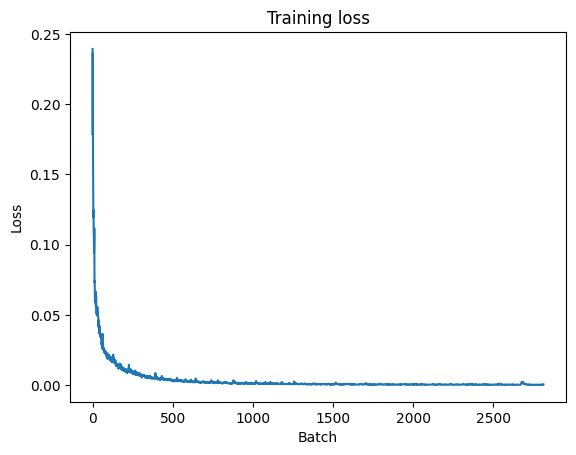

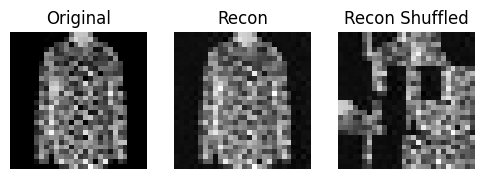

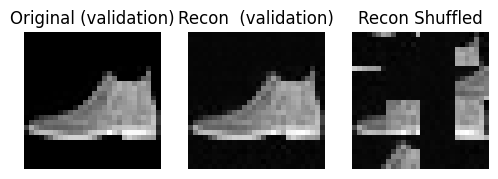

torch.Size([64, 8, 16, 64])
torch.Size([64, 8, 16, 64])
torch.Size([64, 8, 16, 64])
torch.Size([64, 8, 16, 64])
torch.Size([64, 8, 16, 64])
torch.Size([64, 8, 16, 64])
torch.Size([64, 8, 16, 64])
torch.Size([64, 8, 16, 64])


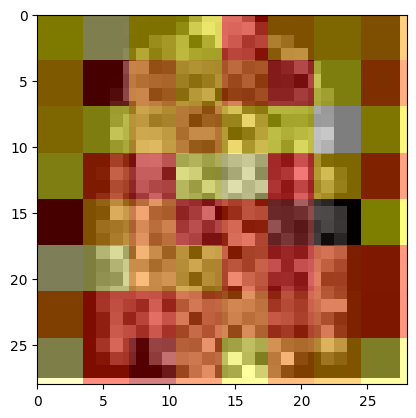

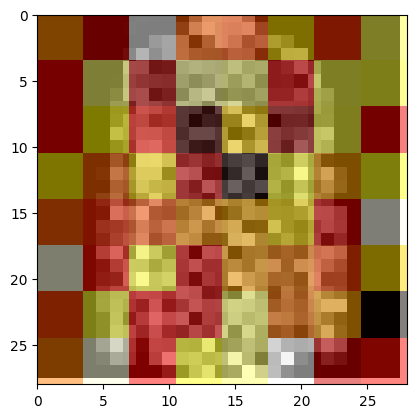

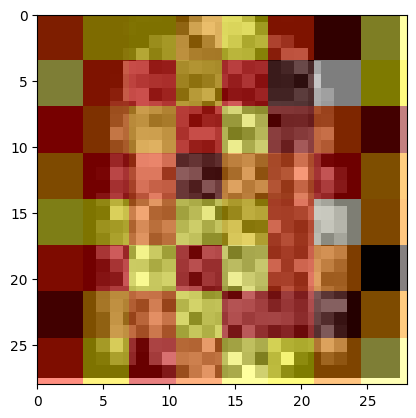

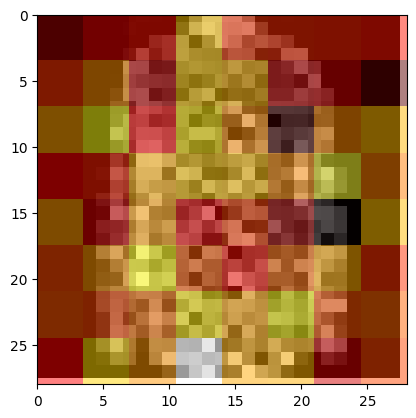

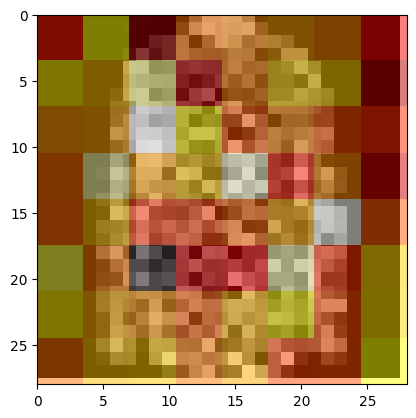

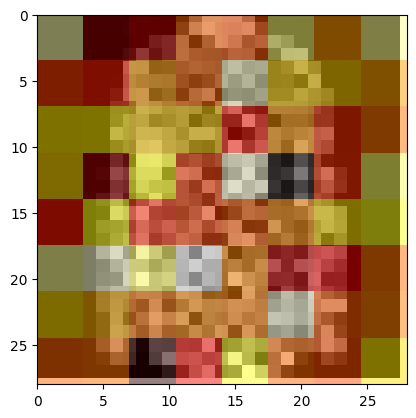

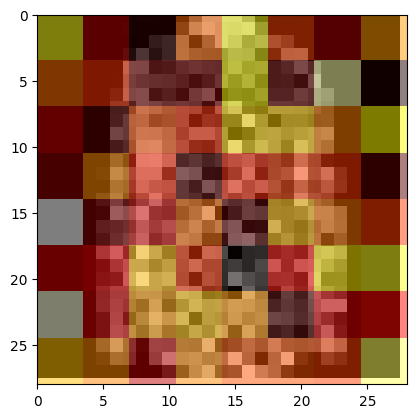

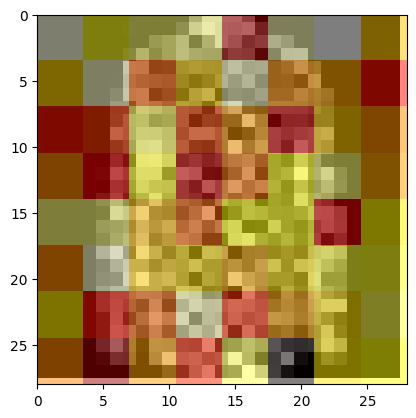

In [263]:
# Plot history loss
plt.figure()
plt.plot(loss_history)
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.title("Training loss")
print("min loss = ", min(loss_history))

# Plot a recon and compare to original
images, labels = next(iter(train_loader))
model.eval()
recons, _ = model(images.to(device))
print("recon loss on shown training recon = ", F.mse_loss(images[0].to(device), recons[0]).item())
print("recon loss on training recon batch = ", F.mse_loss(images.to(device), recons).item())

# Shuffle patches and run a forward pass through ViT model
perm = torch.randperm(model.grid_size**2)
image_patches = patchify(images.to(device), model.patch_size)
z = model.encoder(image_patches[:, perm])
seq = model.decoder(z)
recons_shuffled = unpatchify(seq, model.patch_size, model.grid_size )

# Plot a recon and compare to original
images_val, _ = next(iter(test_loader))
model.eval()
recons_val, _ = model(images_val.to(device))
print("recon loss on shown validation recon = ", F.mse_loss(images_val[0].to(device), recons_val[0]).item())
print("recon loss on validation recon batch = ", F.mse_loss(images_val.to(device), recons_val).item())

# Shuffle patches and run a forward pass through ViT model
perm = torch.randperm(model.grid_size**2)
image_patches = patchify(images_val.to(device), model.patch_size)
z = model.encoder(image_patches[:, perm])
seq = model.decoder(z)
recons_val_shuffled = unpatchify(seq, model.patch_size, model.grid_size )


fig, ax = plt.subplots(1, 3, figsize=(6, 3))
ax[0].imshow(images[0][0].cpu().numpy(), cmap="gray")
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(recons[0][0].detach().cpu().numpy(), cmap="gray")
ax[1].set_title("Recon")
ax[1].axis("off")

ax[2].imshow(recons_shuffled[0][0].detach().cpu().numpy(), cmap="gray")
ax[2].set_title("Recon Shuffled")
ax[2].axis("off")

plt.show()

fig, ax = plt.subplots(1, 3, figsize=(6, 3))
ax[0].imshow(images_val[0][0].cpu().numpy(), cmap="gray")
ax[0].set_title("Original (validation)")
ax[0].axis("off")

ax[1].imshow(recons_val[0][0].detach().cpu().numpy(), cmap="gray")
ax[1].set_title("Recon  (validation)")
ax[1].axis("off")


ax[2].imshow(recons_val_shuffled[0][0].detach().cpu().numpy(), cmap="gray")
ax[2].set_title("Recon Shuffled")
ax[2].axis("off")

plt.show()



model.eval()
enc = model.encoder
x = enc.ff(patchify(images.to(device), 7)) + enc.pos   # trained embed + pos
blk = enc.attn_blocks[1]
_, w = blk.attention(blk.layer_norm1(x)) # trained weights (B, num_heads, grid_size**2, 512/num_head)



grid_size = int((512//8)**0.5)
q=1

for head in range(8):
    # which patch is "looking"
    # heat = w[0, head, q].reshape(grid, grid)   # (4,4): where patch q attends
    heat = einops.rearrange(w[0, head, q], "(g1 g2) ->  g1 g2", g1=grid_size)
    img = images[0][0]
    plt.figure()
    plt.imshow(img.cpu(), cmap="gray")
    plt.imshow(heat.cpu().detach(), alpha=.5, extent=[0,28,28,0], cmap="hot")  # upsamples 4×4 over the image

    print(w.shape)



### OLD plot before positional encoding

min loss =  0.00020588902407325804
recon loss on shown training recon =  0.14412882924079895


C:\Users\Ous\AppData\Local\Temp\ipykernel_37576\2199335700.py:13: UserWarning: Using a target size (torch.Size([64, 1, 28, 28])) that is different to the input size (torch.Size([1, 28, 28])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  print("recon loss on shown training recon = ", F.mse_loss(images[0].to(device), recons[0]).item())


AttributeError: 'tuple' object has no attribute 'size'

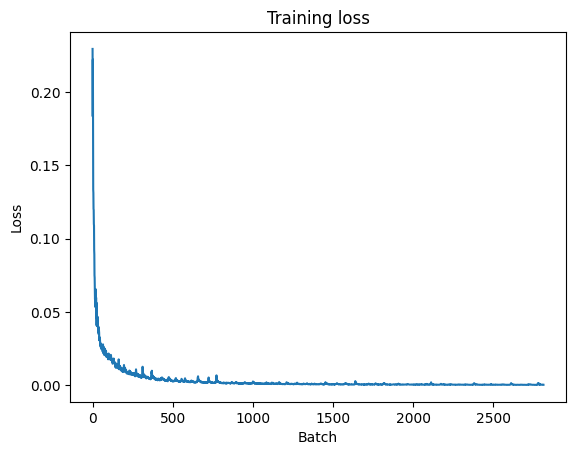

In [89]:
# Plot history loss
plt.figure()
plt.plot(loss_history)
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.title("Training loss")
print("min loss = ", min(loss_history))

# Plot a recon and compare to original
images, labels = next(iter(train_loader))
model.eval()
recons = model(images.to(device))
print("recon loss on shown training recon = ", F.mse_loss(images[0].to(device), recons[0]).item())
print("recon loss on training recon batch = ", F.mse_loss(images.to(device), recons).item())

fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].imshow(images_val[0][0].cpu().numpy(), cmap="gray")
ax[0].set_title("Original (validation)")
ax[0].axis("off")

ax[1].imshow(recons_val[0][0].detach().cpu().numpy(), cmap="gray")
ax[1].set_title("Recon  (validation)")
ax[1].axis("off")

plt.show()




### E2.d. Check permutation Equivariance 

In [ ]:
x, _ = next(iter(train_loader))
x = patchify(x.to(device), 7)
N = x.shape[1] 
perm = torch.randperm(N)
attn = MultiheadAttention(49, 8).to(device)

# attention(shuffle(x)) == shuffle(attention(x))
# That means multihead attention mechanism is permutation-equivariance without positioanl encoding.
# in other words, it can't tell which patch is top-left vs bottom-right 
out1,_ = attn(x)
out2,_ = attn(x[:, perm])
print(torch.allclose(out2, out1[:, perm], atol=1e-5))   # expect True


True


### E3.b. Check permutation equivariance for encoder with positional encoding

In [ ]:
x, _ = next(iter(train_loader))
x = patchify(x.to(device), 7)
N = x.shape[1] 
perm = torch.randperm(N)
attn = MultiheadAttention(49, 8).to(device)
encoder = ViT_Encoder(dim, n_heads, z_dim, patch_size**2, grid_size**2, use_pos=True).to(device)

# attention(shuffle(x)) == shuffle(attention(x))
# That means multihead attention mechanism is permutation-equivariance without positioanl encoding.
# in other words, it can't tell which patch is top-left vs bottom-right 
out1 = encoder(x)
out2 = encoder(x[:, perm])
print(torch.allclose(out2, out1[:, perm], atol=1e-5))   # expect True

encoder = ViT_Encoder(dim, n_heads, z_dim, patch_size**2, grid_size**2, use_pos=False).to(device)

# attention(shuffle(x)) == shuffle(attention(x))
# That means multihead attention mechanism is permutation-equivariance without positioanl encoding.
# in other words, it can't tell which patch is top-left vs bottom-right 
out1 = encoder(x)
out2 = encoder(x[:, perm])
print(torch.allclose(out2, out1[:, perm], atol=1e-5))   # expect True



False
True


In [ ]:
B, N, P = seq.shape
B

64

### E4. CLS token vs pooling

In [ ]:
class ViT_EncoderCLS(nn.Module):
    def __init__(self, dim: int, n_heads: int, z_dim: int, P: int, N: int, k: int = 2, use_pos: bool = True):
        super().__init__()
        self.use_pos = use_pos
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim) * 0.02) # initialize cls token
        self.ff = nn.Sequential(nn.Linear(P, dim), nn.GELU())
                
        # Stack attention blocks
        self.attn_blocks = nn.Sequential(*[AttnBlock(dim, n_heads) for i in range(k)])
        
        # Linear layer to encode to a lower dim 
        self.ff2 = nn.Sequential(nn.GELU(), nn.Linear(dim, 10)) # 10 is number of classes of FashionMNIST
                        
        # Layer for positional encoding
        self.pos = nn.Parameter(torch.randn(1, N + 1, dim) * 0.02) # N = grid_size ** 2 (the +1 is the additional cls token)
        
        
    def forward(self, seq, out_type="cls", return_features=False):
        """
        Args:
            seq (B, N, P) P is patch_size**2 and N is number of patches rows x coloumns
            
        Returns:
            cls_token (B, dim)
        """
        B, N, P = seq.size()
        
        # embed sequence
        x = self.ff(seq)  
        
        # prepend cls token to embedded seq
        cls_token = self.cls_token.expand(B, -1, -1) # (B, 1, dim) expand don't repeat/copy        
        x = torch.cat([cls_token, x], dim=1) # shape becomes (B, N+1, dim)
         
        # positional encoding             
        if self.use_pos:
            x = x + self.pos
        
        # Attention block
        x = self.attn_blocks(x)
                 
        if out_type == "cls":            
            x = x[:, 0] # take only cls token that theoretically averages all other tokens (B, dim)
            
        elif out_type == "mean_pool":
            x = x[:, 1:].mean(dim=1) # mean pool averages all token to (B, dim)
            
        elif out_type == "max_pool":
            x = x[:, 1:].max(dim=1).values # takes max value (B, dim)
            
        if return_features:
            return x
            
        # # project sequence to comrpessed latent vector
        predicted_labels = self.ff2(x)
        
        return predicted_labels


# --- Training Loop ---
# define hyperparams
epochs = 3
dim = 512
n_heads = 8
z_dim = 64
patch_size = 7
grid_size = int(next(iter(train_loader))[0].shape[-1] // patch_size)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# define model
model_cls = ViT_EncoderCLS(dim, n_heads, z_dim, patch_size**2, grid_size**2).to(device)
model_mean = ViT_EncoderCLS(dim, n_heads, z_dim, patch_size**2, grid_size**2).to(device)
model_max = ViT_EncoderCLS(dim, n_heads, z_dim, patch_size**2, grid_size**2).to(device)

# setup optimizer
optimizer_cls = torch.optim.AdamW(model_cls.parameters(), lr=3e-4)
optimizer_mean = torch.optim.AdamW(model_mean.parameters(), lr=3e-4)
optimizer_max = torch.optim.AdamW(model_max.parameters(), lr=3e-4)

# define tracking lists
loss_history_cls = []
loss_history_mean = []
loss_history_max = []

# training loop
for epoch in tqdm(range(epochs)):
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
    
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)
        image_patches = patchify(images, patch_size=patch_size)

        # 1. run forward pass through model
        predicted_labels_cls = model_cls(image_patches, out_type="cls")
        predicted_labels_mean = model_mean(image_patches, out_type="mean_pool")
        predicted_labels_max = model_max(image_patches, out_type="max_pool")
        
        # 2. calculate loss
        loss_cls = F.cross_entropy(predicted_labels_cls, labels)
        loss_mean = F.cross_entropy(predicted_labels_mean, labels)
        loss_max = F.cross_entropy(predicted_labels_max, labels)
        
        # 3. backprop and update weights
        optimizer_cls.zero_grad(); loss_cls.backward(); optimizer_cls.step()
        optimizer_mean.zero_grad(); loss_mean.backward(); optimizer_mean.step()
        optimizer_max.zero_grad(); loss_max.backward(); optimizer_max.step()
        
        # Show live loss
        pbar.set_postfix(loss=loss_cls.item())
        
        # Track loss
        loss_history_cls.append(loss_cls.item())
        loss_history_mean.append(loss_mean.item())
        loss_history_max.append(loss_max.item())

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 1/3:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 2/3:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 3/3:   0%|          | 0/938 [00:00<?, ?it/s]

min loss cls =  0.11137163639068604
min loss mean =  0.08973647654056549
min loss max =  0.09212114661931992


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

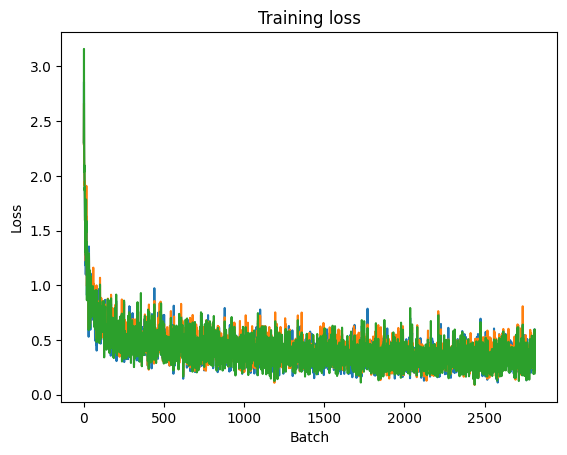

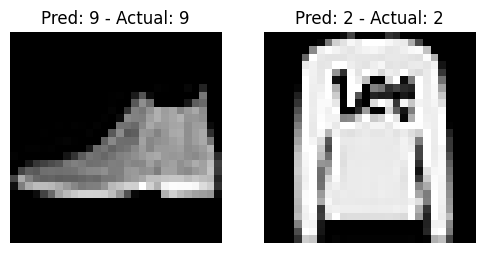

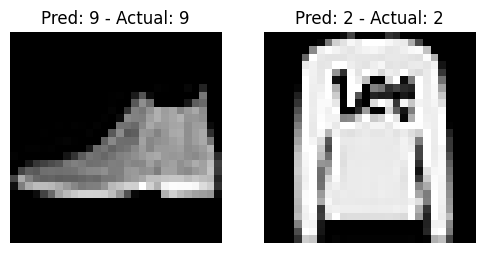

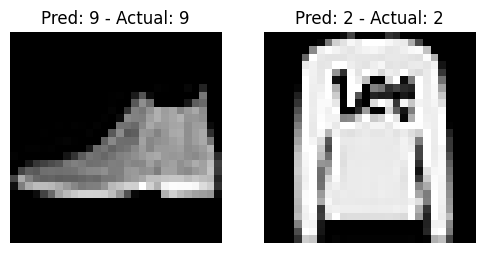

In [ ]:
# Plot history loss
plt.figure()
plt.plot(loss_history_cls)
plt.plot(loss_history_mean)
plt.plot(loss_history_max)
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.title("Training loss")
print("min loss cls = ", min(loss_history_cls))
print("min loss mean = ", min(loss_history_mean))
print("min loss max = ", min(loss_history_max))

# Plot a recon and compare to original
images, labels = next(iter(test_loader))
image_patches = patchify(images.to(device), patch_size=patch_size)
model_cls.eval(); model_mean.eval(); model_max.eval(); 
predicted_labels_cls = model_cls(image_patches, out_type="cls")
predicted_labels_mean = model_mean(image_patches, out_type="mean_pool")
predicted_labels_max = model_max(image_patches, out_type="max_pool")

# plot predictiosn for model_cls
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].imshow(images[0][0].cpu().numpy(), cmap="gray")
ax[0].set_title(f"Pred: {predicted_labels_cls[0].argmax().item()} - Actual: {labels[0].item()}")
ax[0].axis("off")

ax[1].imshow(images[1][0].cpu().numpy(), cmap="gray")
ax[1].set_title(f"Pred: {predicted_labels_cls[1].argmax().item()} - Actual: {labels[1].item()}")
ax[1].axis("off")

# plot predictiosn for model_mean
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].imshow(images[0][0].cpu().numpy(), cmap="gray")
ax[0].set_title(f"Pred: {predicted_labels_mean[0].argmax().item()} - Actual: {labels[0].item()}")
ax[0].axis("off")

ax[1].imshow(images[1][0].cpu().numpy(), cmap="gray")
ax[1].set_title(f"Pred: {predicted_labels_mean[1].argmax().item()} - Actual: {labels[1].item()}")
ax[1].axis("off")

# plot predictiosn for model_max
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].imshow(images[0][0].cpu().numpy(), cmap="gray")
ax[0].set_title(f"Pred: {predicted_labels_max[0].argmax().item()} - Actual: {labels[0].item()}")
ax[0].axis("off")

ax[1].imshow(images[1][0].cpu().numpy(), cmap="gray")
ax[1].set_title(f"Pred: {predicted_labels_max[1].argmax().item()} - Actual: {labels[1].item()}")
ax[1].axis("off")


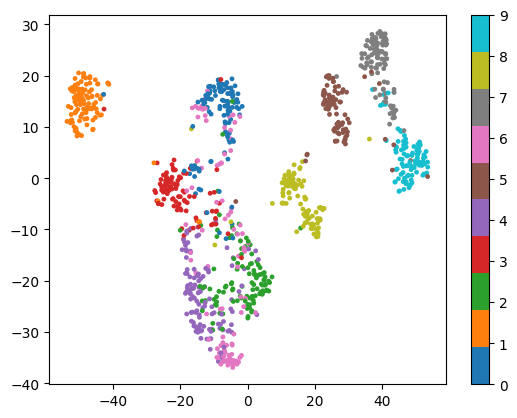

In [ ]:
# plotting features of 1000 images in tsne plot
feats, labs = [], []
model_cls.eval()
with torch.no_grad():
    for imgs, lbls in test_loader:
        patches = patchify(imgs.to(device), patch_size)
        f = model_cls(patches, out_type="cls", return_features=True)   # (B, dim)
        feats.append(f.cpu()) 
        labs.append(lbls)
        if len(feats)*imgs.shape[0] >= 1000: break
feats = torch.cat(feats)[:1000].numpy()
labs  = torch.cat(labs)[:1000].numpy()

from sklearn.manifold import TSNE
emb = TSNE(n_components=2, perplexity=30, init="pca").fit_transform(feats)
plt.scatter(emb[:,0], emb[:,1], c=labs, cmap="tab10", s=6)
plt.colorbar()



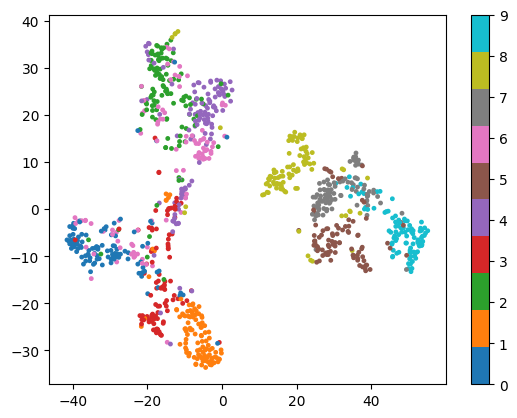

In [ ]:
# plotting features of 1000 images in tsne plot
feats, labs = [], []
model_mean.eval()
with torch.no_grad():
    for imgs, lbls in test_loader:
        patches = patchify(imgs.to(device), patch_size)
        f = model_mean(patches, out_type="cls", return_features=True)   # (B, dim)
        feats.append(f.cpu()) 
        labs.append(lbls)
        if len(feats)*imgs.shape[0] >= 1000: break
feats = torch.cat(feats)[:1000].numpy()
labs  = torch.cat(labs)[:1000].numpy()

from sklearn.manifold import TSNE
emb = TSNE(n_components=2, perplexity=30, init="pca").fit_transform(feats)
plt.scatter(emb[:,0], emb[:,1], c=labs, cmap="tab10", s=6)
plt.colorbar()



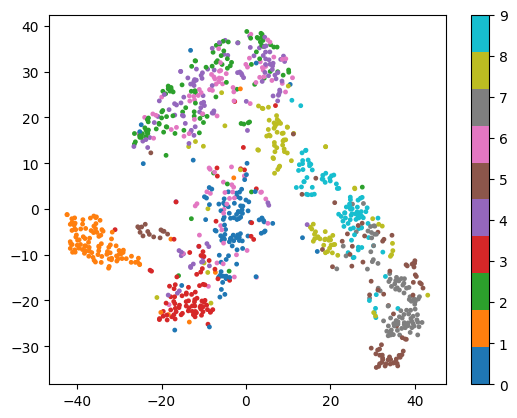

In [ ]:
# plotting features of 1000 images in tsne plot
feats, labs = [], []
model_max.eval()
with torch.no_grad():
    for imgs, lbls in test_loader:
        patches = patchify(imgs.to(device), patch_size)
        f = model_max(patches, out_type="cls", return_features=True)   # (B, dim)
        feats.append(f.cpu()) 
        labs.append(lbls)
        if len(feats)*imgs.shape[0] >= 1000: break
feats = torch.cat(feats)[:1000].numpy()
labs  = torch.cat(labs)[:1000].numpy()

from sklearn.manifold import TSNE
emb = TSNE(n_components=2, perplexity=30, init="pca").fit_transform(feats)
plt.scatter(emb[:,0], emb[:,1], c=labs, cmap="tab10", s=6)
plt.colorbar()



### E5. Freezing ViT autoencoder to see if it makes better representation and classification than ViT encoder classifier


In [ ]:
# define simple classifier
class Classifier(nn.Module):
    def __init__(self, z_dim):
        super().__init__()
        self.ff = nn.Sequential(nn.Linear(z_dim*16, 64), nn.ReLU(), nn.Linear(64, 10))
        
    def forward(self, x):
        x = einops.rearrange(x, "... n z -> ... (n z)")
        
        x = self.ff(x)
        return x

classifier = Classifier(z_dim).to(device)
model.eval()

for p in model.parameters():
    p.requires_grad = False

# setup optimizer
optimizer = torch.optim.AdamW(classifier.parameters(), lr=3e-4)

# define tracking lists
loss_history = []

# training loop
for epoch in tqdm(range(epochs)):
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
    
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)

        # 1. run forward pass through model
        recon, z = model(images)
        predicted_labels = classifier(z)
        
        # 2. calculate loss
        loss = F.cross_entropy(predicted_labels, labels)
        
        # 3. backprop and update weights
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Show live loss
        pbar.set_postfix(loss=loss.item())
        
        # Track loss
        loss_history.append(loss.item())

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 1/3:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 2/3:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 3/3:   0%|          | 0/938 [00:00<?, ?it/s]

min loss =  0.2328873723745346


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

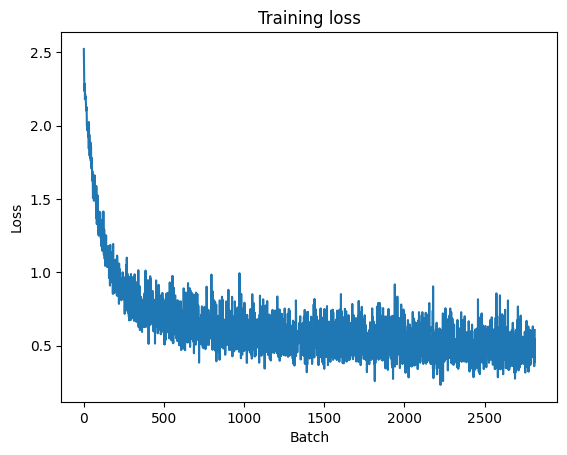

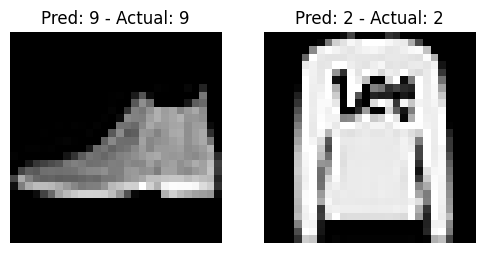

In [ ]:
# Plot history loss
plt.figure()
plt.plot(loss_history)
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.title("Training loss")
print("min loss = ", min(loss_history))


# Plot a recon and compare to original
images, labels = next(iter(test_loader))
images = images.to(device)
classifier.eval()
recon, z = model(images)
predicted_labels = classifier(z)

# plot predictiosn for model_cls
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].imshow(images[0][0].cpu().numpy(), cmap="gray")
ax[0].set_title(f"Pred: {predicted_labels[0].argmax().item()} - Actual: {labels[0].item()}")
ax[0].axis("off")

ax[1].imshow(images[1][0].cpu().numpy(), cmap="gray")
ax[1].set_title(f"Pred: {predicted_labels[1].argmax().item()} - Actual: {labels[1].item()}")
ax[1].axis("off")




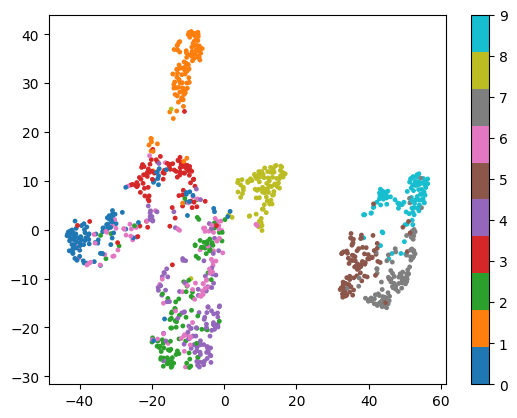

In [ ]:
# plotting features of 1000 images in tsne plot
feats, labs = [], []
classifier.eval()
model.eval()
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        _, z = model(imgs)
        f = einops.rearrange(z, "... n z -> ... (n z)")
        f = classifier(z)
        feats.append(f.cpu()) 
        labs.append(lbls)
        if len(feats)*imgs.shape[0] >= 1000: break
feats = torch.cat(feats)[:1000].numpy()
labs  = torch.cat(labs)[:1000].numpy()

from sklearn.manifold import TSNE
emb = TSNE(n_components=2, perplexity=30, init="pca").fit_transform(feats)
plt.scatter(emb[:,0], emb[:,1], c=labs, cmap="tab10", s=6)
plt.colorbar()


## 1.5 - Improvind Transformer efficiency

### E7. Measuring efficency of Multi-Head Attention (MHA)
There are two main costs, memory and compute. 
Compute is obvious, more token => more matmul multiplication.
Memory is harder to see. A tensor has to physically sit in VRAM before running softmax. Given a tensor of shape (B, N, D, D), its memory grows by D^2.

For example if D=16 -> 16 x 16 = 256 cells. But for D=1024, that is 1 million cells!

We will sweep different params, see how they measure in terms of time and memory.

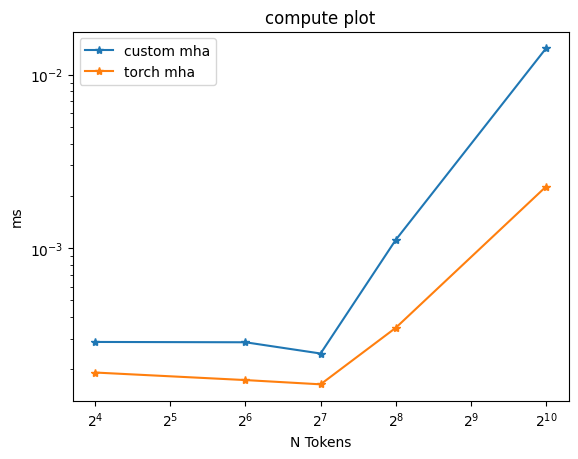

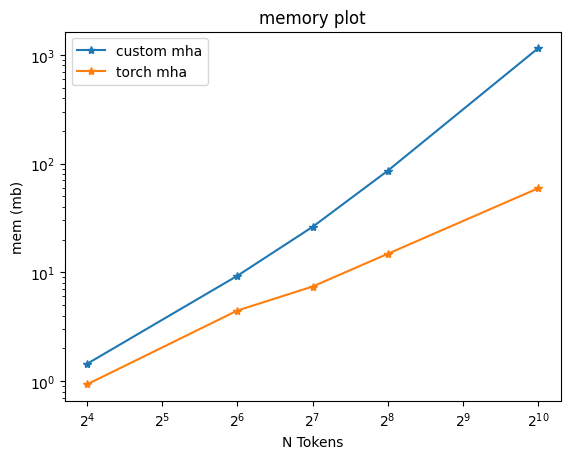

In [167]:
mem_dict = {}
mem_dict_torch = {}
compute_time_dict = {}
compute_time_dict_torch = {}
N = [16, 64, 128, 256, 1024]
seq_len = 8
n_heads = 8
iterations = 20
import time
import numpy as np

def measure_fn(fn):
    # Reset memory
    torch.cuda.empty_cache()        
    torch.cuda.reset_peak_memory_stats()
    current_mem = torch.cuda.max_memory_allocated() 
    
    # Start timer
    torch.cuda.synchronize()
    t0 = time.perf_counter()    

    # Run attn
    fn()
    
    # Measure computation time
    torch.cuda.synchronize()
    elapsed = time.perf_counter() - t0
    
    # Measure memory
    with torch.no_grad():
        mem_stat = torch.cuda.max_memory_allocated()
    mem = (mem_stat - current_mem) / 1e6
    
    return elapsed, mem

# Reset memory
torch.cuda.empty_cache()        
torch.cuda.reset_peak_memory_stats()
        
for n in N:
    mha = MultiheadAttention(128, n_heads).to(device)
    mha_torch = nn.MultiheadAttention(128, n_heads, batch_first=True, bias=False).to(device)
    mem_list = []
    compute_time_list = []
    mem_list_torch = []
    compute_time_list_torch = []
    
    # quick warmup
    for i in range (2):
        x = torch.randn((16, n, 128)).to(device)
        _ = measure_fn(lambda: mha(x))
        _ = measure_fn(lambda: mha_torch(x,x,x, need_weights=False))

    for i in range(iterations):
        x = torch.randn((16, n, 128)).to(device)
        
        # Measure custom mha
        elapsed, mem = measure_fn(lambda: mha(x))
        compute_time_list.append(elapsed)                
        mem_list.append(mem)
        
        # Measure Torch mha
        elapsed, mem = measure_fn(lambda: mha_torch(x,x,x, need_weights=False))
        compute_time_list_torch.append(elapsed)                
        mem_list_torch.append(mem)
            
        # Save list result to dict
        mem_dict[str(n)] = np.mean(mem_list) 
        compute_time_dict[str(n)] = np.mean(compute_time_list)
        mem_dict_torch[str(n)] = np.mean(mem_list_torch) 
        compute_time_dict_torch[str(n)] = np.mean(compute_time_list_torch)

        
# plot
plt.figure()
plt.plot(N,compute_time_dict.values(), marker="*", label="custom mha")
plt.plot(N,compute_time_dict_torch.values(), marker="*", label="torch mha")
plt.ylabel("ms")
plt.xlabel("N Tokens")
plt.yscale("log")
plt.title("compute plot")
plt.xscale("log", base=2)
plt.legend()

plt.figure()
plt.plot(N,mem_dict.values(), marker="*", label="custom mha")
plt.plot(N,mem_dict_torch.values(), marker="*", label="torch mha")
plt.ylabel("mem (mb)")
plt.xlabel("N Tokens")
plt.title("memory plot")
plt.yscale("log")
plt.xscale("log", base=2)
plt.legend()




In [170]:
mt = nn.MultiheadAttention(128, 8, batch_first=True, bias=False).to(device)
W_perm = einops.rearrange(mha.proj.weight, "(h three hd) d -> (three h hd) d", h=n_heads, three=3)

mt.in_proj_weight.data.copy_(W_perm)   # (3*128, 128)
mt.out_proj.weight.data.copy_(mha.to_out.weight.data)
my, _ = mha(x)
to, _ = mt(x, x, x, need_weights=False)
print((my - to).abs().max())


tensor(7.0781e-08, device='cuda:0', grad_fn=<MaxBackward1>)


### Testing custom MHA with F.scaled_dot_product_attn which supposefly fuses kernal and does flash attn

In [ ]:
class FlashMultiheadAttention(nn.Module):
    def __init__(self, dim: int, n_heads: int):
        super().__init__()
        self.head_dim = dim // n_heads
        self.n_heads = n_heads
        self.proj = nn.Linear(dim, 3 * self.head_dim * n_heads, bias=False)
        
        # The last layer that fuses multiple attention heads into a single layer
        self.to_out = nn.Linear(self.head_dim * n_heads, dim, bias=False)

        
    def forward(self, seq, get_attn_matrix=False):
        """
        Args:
            seq (B, N, dim)
            
        Returns:
            out: (B, N, dim)
            attention: (B, n_heads, N, dim)
        """
        # project to Q, K and V
        qkv = self.proj(seq)
        # Rearrange to move head outside to perform attention calucation PER head        
        qkv = einops.rearrange(qkv, "b n (h d) -> b h n d", h = self.n_heads)
        # Divide d into 3 chunks d/3 for each query, key and value
        q, k, v = qkv.chunk(3, dim=-1)
               
        attention = None
        if get_attn_matrix:
            # Dot product of Queries and Keys
            score_matrix = einops.einsum(q, k, "... n1 d, ... n2 d -> ... n1 n2") # contracted dimension much share same var name in einops (here it is 'd')
            
            # # scale by head size
            score_matrix = score_matrix / (self.head_dim**0.5)
            
            # # Applying softmax to the score matrix
            attention = torch.softmax(score_matrix, dim=-1)
            
            # # Weighting attention by the value
            # out = attention @ v
        
        # Torch's flash attention formula, same result just faster. Also commonly known as "SDPA"
        out = F.scaled_dot_product_attention(q, k, v, is_causal=False) # (B, num_heads, N, head_dim)
        
        # Move heads back to dim
        out = einops.rearrange(out, "b h n d -> b n (h d)")
        
        # Fuse multi-heads int a linear layer
        out = self.to_out(out)
        
        return out, attention   




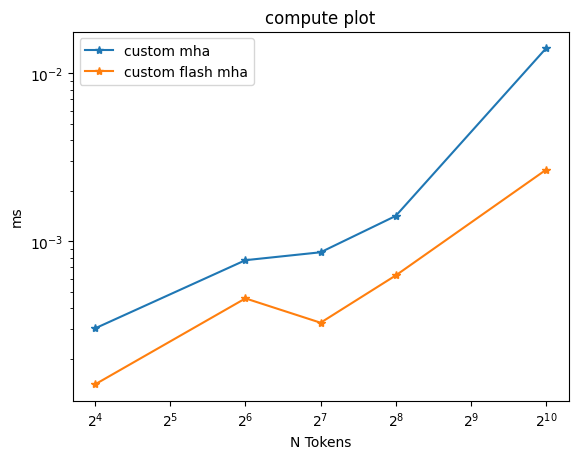

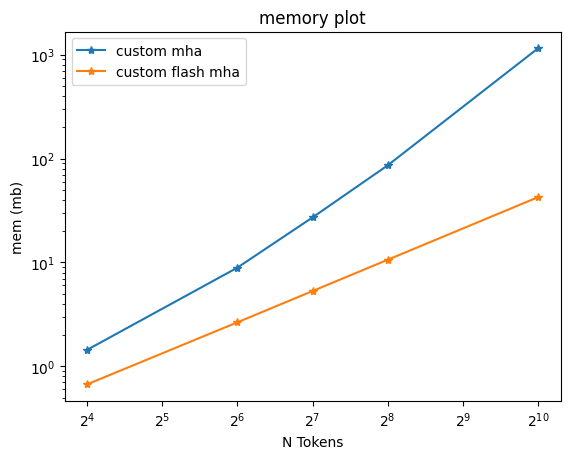

In [41]:
mem_dict = {}
mem_dict_torch = {}
compute_time_dict = {}
compute_time_dict_torch = {}
N = [16, 64, 128, 256, 1024]
seq_len = 8
n_heads = 8
iterations = 20
import time
import numpy as np

def measure_fn(fn):
    # Reset memory
    torch.cuda.empty_cache()        
    torch.cuda.reset_peak_memory_stats()
    current_mem = torch.cuda.max_memory_allocated() 
    
    # Start timer
    torch.cuda.synchronize()
    t0 = time.perf_counter()    

    # Run attn
    fn()
    
    # Measure computation time
    torch.cuda.synchronize()
    elapsed = time.perf_counter() - t0
    
    # Measure memory
    with torch.no_grad():
        mem_stat = torch.cuda.max_memory_allocated()
    mem = (mem_stat - current_mem) / 1e6
    
    return elapsed, mem

# Reset memory
torch.cuda.empty_cache()        
torch.cuda.reset_peak_memory_stats()
        
for n in N:
    mha = MultiheadAttention(128, n_heads).to(device)
    mha_torch = FlashMultiheadAttention(128, n_heads).to(device)
    mem_list = []
    compute_time_list = []
    mem_list_torch = []
    compute_time_list_torch = []
    
    # quick warmup
    for i in range (2):
        x = torch.randn((16, n, 128)).to(device)
        _ = measure_fn(lambda: mha(x))
        _ = measure_fn(lambda: mha_torch(x))

    for i in range(iterations):
        x = torch.randn((16, n, 128)).to(device)
        
        # Measure custom mha
        elapsed, mem = measure_fn(lambda: mha(x))
        compute_time_list.append(elapsed)                
        mem_list.append(mem)
        
        # Measure Torch mha
        elapsed, mem = measure_fn(lambda: mha_torch(x))
        compute_time_list_torch.append(elapsed)                
        mem_list_torch.append(mem)
            
        # Save list result to dict
        mem_dict[str(n)] = np.mean(mem_list) 
        compute_time_dict[str(n)] = np.mean(compute_time_list)
        mem_dict_torch[str(n)] = np.mean(mem_list_torch) 
        compute_time_dict_torch[str(n)] = np.mean(compute_time_list_torch)

        
# plot
plt.figure()
plt.plot(N,compute_time_dict.values(), marker="*", label="custom mha")
plt.plot(N,compute_time_dict_torch.values(), marker="*", label="custom flash mha")
plt.ylabel("ms")
plt.xlabel("N Tokens")
plt.yscale("log")
plt.title("compute plot")
plt.xscale("log", base=2)
plt.legend()

plt.figure()
plt.plot(N,mem_dict.values(), marker="*", label="custom mha")
plt.plot(N,mem_dict_torch.values(), marker="*", label="custom flash mha")
plt.ylabel("mem (mb)")
plt.xlabel("N Tokens")
plt.title("memory plot")
plt.yscale("log")
plt.xscale("log", base=2)
plt.legend()




In [188]:
mt = FlashMultiheadAttention(128, 8).to(device)

mt.proj.weight.data.copy_(mha.proj.weight)   # (3*128, 128)
mt.to_out.weight.data.copy_(mha.to_out.weight.data)
my, _ = mha(x)
to, _ = mt(x)
print(my.shape, to.shape)
print((my - to).abs().max())


torch.Size([16, 1024, 128]) torch.Size([16, 1024, 128])
tensor(6.7055e-08, device='cuda:0', grad_fn=<MaxBackward1>)


Visualizing Attention mask

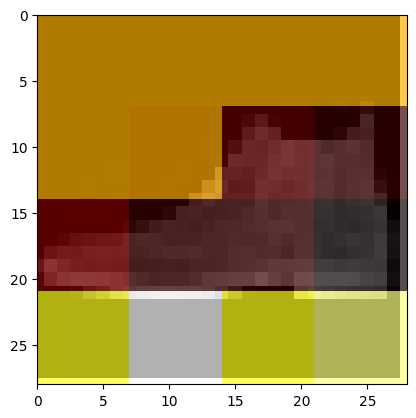

In [257]:
dim = 128
mha = FlashMultiheadAttention(dim, n_heads).to(device)
images, labels = next(iter(test_loader))
patches = patchify(images.to(device), 7)
ff = nn.Sequential(nn.Linear(7**2, dim), nn.GELU()).to(device)
_, w = mha(ff(patches),get_attn_matrix=True ) # w is of shape (B, num_heads, grid_size**2, 512/num_head)

q = 5  
head = 1
grid_size = int((128//8)**0.5)
# which patch is "looking"
# heat = w[0, head, q].reshape(grid, grid)   # (4,4): where patch q attends
heat = einops.rearrange(w[0, head, q], "(g1 g2) ->  g1 g2", g1=grid_size)
img = images[0][0]
plt.imshow(img.cpu(), cmap="gray")
plt.imshow(heat.cpu().detach(), alpha=.7, extent=[0,28,28,0], cmap="hot")  # upsamples 4×4 over the image



### Below, we explore MHA vs MQA vs GQA. 

MQA is Multi Query Attention.
GQA is Grouped Query Attention.

They exist mainly for shrinking KV cache by redufing KV heads with minimal to no quality loss.

In [31]:
x = 4 % 3
assert 4%2 == 0, "x must be a positive number"  # Passes silently

In [55]:
class GQA(nn.Module):
    def __init__(self, dim: int, n_heads: int, n_kv_heads: int):
        super().__init__()
        self.head_dim = dim // n_heads
        self.n_heads = n_heads
        self.n_kv_heads = n_kv_heads        
        assert self.n_heads % self.n_kv_heads == 0, "num of kv heads must be divisible by num of heads to repeat_interleave"
        
        # self.proj = nn.Linear(dim, 3 * self.head_dim * n_heads, bias=False)
        self.proj_to_q = nn.Linear(dim, n_heads * self.head_dim) # N head for Q (Query)
        self.proj_to_kv = nn.Linear(dim, 2 * n_kv_heads * self.head_dim) # One head for K and V (Keys and Values) in MQA
        
        # The last layer that fuses multiple attention heads into a single layer
        self.to_out = nn.Linear(self.head_dim * n_heads, dim, bias=False)

        
    def forward(self, seq, get_attn_matrix=False):
        """
        Args:
            seq (B, N, dim)
            
        Returns:
            out: (B, N, dim)
            attention: (B, n_heads, N, dim)
        """
        # project to Q, K and V
        q = self.proj_to_q(seq)
        kv = self.proj_to_kv(seq)
        
        # Rearrange to move head outside to perform attention calucation PER head        
        q = einops.rearrange(q, "b n (num_heads head_dim) -> b num_heads n head_dim", num_heads = self.n_heads)
        kv = einops.rearrange(kv, "b n (num_kv_heads head_dim) -> b num_kv_heads n head_dim", num_kv_heads = self.n_kv_heads)
        
        # Divide d into 3 chunks d/3 for each query, key and value
        k, v = kv.chunk(2, dim=-1)     
        
        # Expand k and v to match q for matrix multiplication. so heads [A, B]  →  [A, A, A, A, B, B, B, B]
        k = k.repeat_interleave(self.n_heads // self.n_kv_heads, dim=1)
        v = v.repeat_interleave(self.n_heads // self.n_kv_heads, dim=1)   
               
        attention = None
        if get_attn_matrix:
            
        
            # Dot product of Queries and Keys
            score_matrix = einops.einsum(q, k, "... n1 d, ... n2 d -> ... n1 n2") # contracted dimension much share same var name in einops (here it is 'd')
            
            # # scale by head size
            score_matrix = score_matrix / (self.head_dim**0.5)
            
            # # Applying softmax to the score matrix
            attention = torch.softmax(score_matrix, dim=-1)       
       
        out = F.scaled_dot_product_attention(q, k, v, is_causal=False) # (B, num_heads, N, head_dim)
        
        # Move heads back to dim
        out = einops.rearrange(out, "b h n d -> b n (h d)")
        
        # Fuse multi-heads int a linear layer
        out = self.to_out(out)
        
        return out, attention   




Now we measure speed of MHA vs MQA vs GQA.
Result show they don't really improve in terms of memory and compute time over MHA, they just make KV cache smaller I guess?
Anyway, we can avoid it in research.

also, enable_gqa=True made memory and compute worse with GQA and MQA, so I had to interleave k and v manually

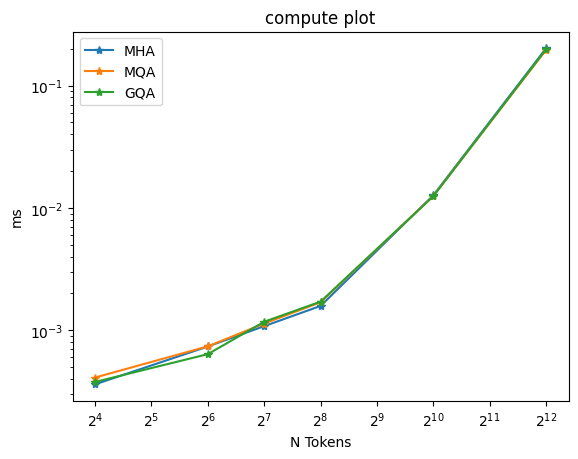

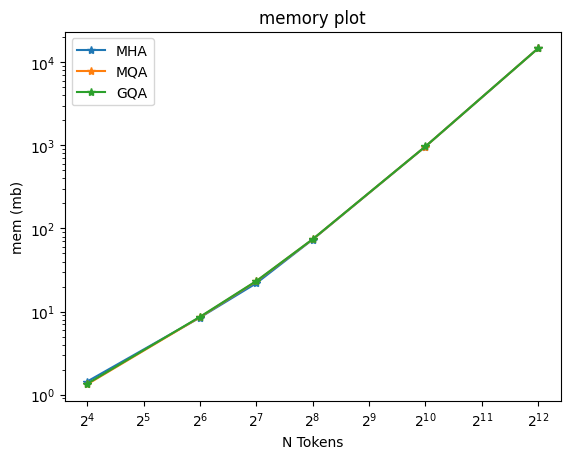

In [75]:
mem_dict_MHA = {}
mem_dict_MQA = {}
mem_dict_GQA = {}
compute_time_dict_MHA = {}
compute_time_dict_MQA = {}
compute_time_dict_GQA = {}
N = [16, 64, 128, 256, 1024, 4096]
seq_len = 8
n_heads = 6
iterations = 20
import time
import numpy as np

def measure_fn(fn):
    # Reset memory
    torch.cuda.empty_cache()        
    torch.cuda.reset_peak_memory_stats()
    current_mem = torch.cuda.max_memory_allocated() 
    
    # Start timer
    torch.cuda.synchronize()
    t0 = time.perf_counter()    

    # Run attn
    fn()
    
    # Measure computation time
    torch.cuda.synchronize()
    elapsed = time.perf_counter() - t0
    
    # Measure memory
    with torch.no_grad():
        mem_stat = torch.cuda.max_memory_allocated()
    mem = (mem_stat - current_mem) / 1e6
    
    return elapsed, mem

# Reset memory
torch.cuda.empty_cache()        
torch.cuda.reset_peak_memory_stats()
        
for n in N:
    mha = FlashMultiheadAttention(128, n_heads).to(device).half()
    mqa = GQA(128, n_heads, 1).to(device).half()
    gqa = GQA(128, n_heads, 2).to(device).half()
    
    mem_list_mha = []
    compute_time_list_mha = []
    mem_list_mqa = []
    compute_time_list_mqa = []
    mem_list_gqa = []
    compute_time_list_gqa = []
    
    # quick warmup
    for i in range (2):
        x = torch.randn((16, n, 128)).to(device).half()
        _ = measure_fn(lambda: mha(x))
        _ = measure_fn(lambda: mqa(x))
        _ = measure_fn(lambda: gqa(x))

    for i in range(iterations):
        x = torch.randn((16, n, 128)).to(device).half()
        
        # Measure MHA
        elapsed, mem = measure_fn(lambda: mha(x))
        compute_time_list_mha.append(elapsed)                
        mem_list_mha.append(mem)
        
        # Measure MQA
        elapsed, mem = measure_fn(lambda: mqa(x))
        compute_time_list_mqa.append(elapsed)                
        mem_list_mqa.append(mem)
        
        # Measure GQA
        elapsed, mem = measure_fn(lambda: gqa(x))
        compute_time_list_gqa.append(elapsed)                
        mem_list_gqa.append(mem)
            
        # Save list result to dict
        mem_dict_MHA[str(n)] = np.mean(mem_list_mha) 
        compute_time_dict_MHA[str(n)] = np.mean(compute_time_list_mha)
        mem_dict_MQA[str(n)] = np.mean(mem_list_mqa) 
        compute_time_dict_MQA[str(n)] = np.mean(compute_time_list_mqa)
        mem_dict_GQA[str(n)] = np.mean(mem_list_gqa) 
        compute_time_dict_GQA[str(n)] = np.mean(compute_time_list_gqa)

        
# plot
plt.figure()
plt.plot(N,compute_time_dict_MHA.values(), marker="*", label="MHA")
plt.plot(N,compute_time_dict_MQA.values(), marker="*", label="MQA")
plt.plot(N,compute_time_dict_GQA.values(), marker="*", label="GQA")
plt.ylabel("ms")
plt.xlabel("N Tokens")
plt.yscale("log")
plt.title("compute plot")
plt.xscale("log", base=2)
plt.legend()

plt.figure()
plt.plot(N,mem_dict_MHA.values(), marker="*", label="MHA")
plt.plot(N,mem_dict_MQA.values(), marker="*", label="MQA")
plt.plot(N,mem_dict_GQA.values(), marker="*", label="GQA")
plt.ylabel("mem (mb)")
plt.xlabel("N Tokens")
plt.title("memory plot")
plt.yscale("log")
plt.xscale("log", base=2)
plt.legend()




### RoPE
Now we replace positional encoding with RoPE. 
Instead of adding a learned position vector to eavh token, RoPE rotates q and k by an angle propotional to their position inside the attention mechanism itself. After rotation, q_i and k_i depend only on (i-j) which is the relative position between patches (not their absolute slots). So even though q_i and k_i are absolute positions, we only care about the distance between them (or the angle in this case since q_i and k_i are angles)

This means our attention mechanism now works for sequence lengths it never trained on (no need to have a fixed dim for positional params anymore). So if we trained on a sentence with a max sequence length of 128 tokens, we can use the same model on a longer sequence of tokens and it will run (whether it will generalize or not is another question).



In [21]:

def rotate_pairs(x, angles):
    """
    x: (B, n_heads, seq_len (N), head_dim)
    angles: (B, n_heads, seq_len (N), head_dim/2)
    """
    N = x.shape[-2]
    # [:N] ensures we our angles are clipped up to sequence length of data input
    cos = angles.cos()[:N][None, None, :, :]
    sin = angles.sin()[:N][None, None, :, :]
    
    x_even = x[..., 0::2]
    x_odd = x[..., 1::2]
    
    # Applying rotation parts in euclidean space
    x_rotated = torch.empty_like(x)
    x_rotated[..., 0::2] = x_even * cos - x_odd * sin
    x_rotated[..., 1::2] = x_even * sin + x_odd * cos

    return x_rotated

def build_rope_1d_cache(N, head_dim, device, base=10000):
    assert head_dim%2==0, "head dimension must be even to apply rotation to it"
    
    positions = torch.arange(N, device=device)    
    inverse_frequences = base ** (-torch.arange(0, head_dim, 2, device=device).float() / head_dim)
    
    # Getting angles (shape: (N, head_dim/2))
    # angles = positions[:, None] * inverse_frequences[None, :]
    angles = einops.einsum(positions, inverse_frequences, "n, d -> n d")
    
    return angles
    

def apply_rope_1d(x, angles):
    """
    Rotates 2 pairs of dim
    Args:
        x (B, num_heads, seq_len (N), head_dim)
        angles: (N, head_dim / 2)
    """    
    x_rotated = rotate_pairs(x, angles)

    return x_rotated


def build_rope_2d_cache(grid_size, head_dim, device, base=10000):
    """
    NOTE: this only works for square grids now since we assume one grid size    
    """
    assert head_dim%4==0, "head dimension must be divisible by 4 to apply 2D rotation to it"
    half_dim = head_dim // 2
    
    pos_y, pos_x = torch.meshgrid(
        torch.arange(grid_size, device=device),
        torch.arange(grid_size, device=device),
        indexing="ij",
    )
    
    pos_y = pos_y.reshape(-1)    
    pos_x = pos_x.reshape(-1)
    
    inverse_frequences = base ** (-torch.arange(0, half_dim, 2, device=device).float() / half_dim)
    
    # Getting angles (shape: (N, head_dim/2))
    # angles = positions[:, None] * inverse_frequences[None, :]
    angles_y = einops.einsum(pos_y.float(), inverse_frequences, "n, d -> n d")
    angles_x = einops.einsum(pos_x.float(), inverse_frequences, "n, d -> n d")
    
    return angles_y, angles_x
    

def apply_rope_2d(x, angles_yx):
    """
    Rotates 2 pairs of dim, thus rope_2d
    Args:
        x (B, num_heads, seq_len (N), head_dim)
        angles: Tuple of 2 (N, head_dim / 2)
    """    
    angles_y = angles_yx[0]
    angles_x = angles_yx[1]
    B, n_heads, N, D = x.size()
    D_half = D//2
    
    x_y = x[..., :D_half]
    x_x = x[..., D_half:]
    
    x_rotated_y = rotate_pairs(x_y, angles_y)
    x_rotated_x = rotate_pairs(x_x, angles_x)
    
    return torch.cat([x_rotated_y, x_rotated_x], dim=-1)

    

class MHA_RoPE(nn.Module):
    def __init__(self, dim: int, n_heads: int, use_rope: str | None = "2d"):
        super().__init__()
        self.head_dim = dim // n_heads
        self.n_heads = n_heads
        self.use_rope = use_rope
        self.proj = nn.Linear(dim, 3 * self.head_dim * n_heads, bias=False)
        
        # The last layer that fuses multiple attention heads into a single layer
        self.to_out = nn.Linear(self.head_dim * n_heads, dim, bias=False)
        
        # If a model was trained with RoPE, it should use RoPE even during inference
        if use_rope is not None:
            # Registering empty cache for rope angles
            # this is similar to saying self.rope_angles = build_cache(), but they now show in model.state_dict(). 
            # persistant = False means the params wont be saved when saving model
            # buffer cannot be optimized unlike nn.Parameter.
            
            if use_rope == "2d":
                self.register_buffer("rope_angles_y", None, persistent=False)
                self.register_buffer("rope_angles_x", None, persistent=False)

            else:
                self.register_buffer("rope_angles", None, persistent=False)         

        
    def forward(self, seq, get_attn_matrix=False):
        """
        Args:
            seq (B, N, dim)
            
        Returns:
            out: (B, N, dim)
            attention: (B, n_heads, N, dim)
        """
        B, N, dim = seq.size()
        
        # project to Q, K and V
        qkv = self.proj(seq)
        # Rearrange to move head outside to perform attention calucation PER head        
        qkv = einops.rearrange(qkv, "b n (h d) -> b h n d", h = self.n_heads)
        # Divide d into 3 chunks d/3 for each query, key and value
        q, k, v = qkv.chunk(3, dim=-1)
                        
        if self.use_rope is not None and self.use_rope=="2d":
            # Build rope angle matrix if not build or if sequence length increased
            if (self.rope_angles_y is None) or (self.rope_angles_y.shape[0]) < N:
                grid_size = int(N**0.5)
                assert grid_size * grid_size == N # todo change to non-square grid size rope
                self.rope_angles_y, self.rope_angles_x = build_rope_2d_cache(grid_size, self.head_dim, seq.device)
                
            q = apply_rope_2d(q, (self.rope_angles_y, self.rope_angles_x))
            k = apply_rope_2d(k, (self.rope_angles_y, self.rope_angles_x))
        
        elif self.use_rope is not None:
            # Build rope angle matrix if not build or if sequence length increased
            if (self.rope_angles is None) or (self.rope_angles.shape[0]) < N:
                self.rope_angles = build_rope_1d_cache(N, self.head_dim, seq.device)
                
            q = apply_rope_1d(q, self.rope_angles)
            k = apply_rope_1d(k, self.rope_angles)            
               
        attention = None
        
        if get_attn_matrix:
            # Dot product of Queries and Keys
            score_matrix = einops.einsum(q, k, "... n1 d, ... n2 d -> ... n1 n2") # contracted dimension much share same var name in einops (here it is 'd')
            
            # # scale by head size
            score_matrix = score_matrix / (self.head_dim**0.5)
            
            # # Applying softmax to the score matrix
            attention = torch.softmax(score_matrix, dim=-1)
            
            # # Weighting attention by the value
            # out = attention @ v
        
        # Torch's flash attention formula, same result just faster. Also commonly known as "SDPA"
        out = F.scaled_dot_product_attention(q, k, v, is_causal=False) # (B, num_heads, N, head_dim)
        
        # Move heads back to dim
        out = einops.rearrange(out, "b h n d -> b n (h d)")
        
        # Fuse multi-heads int a linear layer
        out = self.to_out(out)
        
        return out, attention   

# Example
mha = MHA_RoPE(dim=768, n_heads=12).to(device)

x1 = torch.randn(2, 64, 768).to(device)
y1, _ = mha(x1)

x2 = torch.randn(2, 144, 768).to(device)
y2, _ = mha(x2)

x3 = torch.randn(2, 196, 768).to(device)
y3, _ = mha(x3)


class AttnBlock(nn.Module):
    def __init__(self, dim: int, n_heads: int, use_pos: bool = False, attn_multiple: int = 4):
        super().__init__()
        self.attention = MHA_RoPE(dim, n_heads, use_rope=not use_pos)
        self.layer_norm1 = nn.LayerNorm(dim)
        self.layer_norm2 = nn.LayerNorm(dim)
        self.ff = nn.Sequential(
            nn.Linear(dim, attn_multiple * dim),
            nn.GELU(),
            nn.Linear(attn_multiple * dim, dim)
        )        
                    
    def forward(self, x):
        # attending to tokens across patches with a residual
        out, _ = self.attention(self.layer_norm1(x))
        x = x + out
        
        # channel mixing per token - a "scratch space" to make sense of the tokens we attended to
        out = self.ff(self.layer_norm2(x))
        x = x + out
        
        return x

Next, we define ViT autoencoder with RoPE attention this time

In [ ]:
class ViT_Encoder(nn.Module):
    def __init__(self, dim: int, n_heads: int, z_dim: int, P: int, N: int, use_pos: bool, k: int = 2):
        super().__init__()
        
        self.ff = nn.Sequential(nn.Linear(P, dim), nn.GELU())
                
        # Stack attention blocks
        self.attn_blocks = nn.Sequential(*[AttnBlock(dim, n_heads, use_pos=use_pos) for i in range(k)])
        
        # Linear layer to encode to a lower dim (not sure if we should use GELU here or not)
        self.ff2 = nn.Sequential(nn.GELU(), nn.Linear(dim, z_dim))
                        
        # Layer for positional encoding
        self.pos = nn.Parameter(torch.randn(1, N, dim) * 0.02) # N = grid_size ** 2
        self.use_pos = use_pos
        
        
    def forward(self, seq):
        """
        Args:
            seq (B, N, P) P is patch_size**2 and N is number of patches rows x coloumns
            
        Returns:
            z (B, N, z_dim)
        """
        # embed sequence
        x = self.ff(seq)   
        
        # positional encoding             
        if self.use_pos:
            x = x + self.pos
        
        # Attention block
        x = self.attn_blocks(x)
        
        # project sequence to comrpessed latent vector
        z = self.ff2(x)
        return z
    
    
class ViT_Decoder(nn.Module):
    def __init__(self, dim: int, n_heads: int, z_dim: int, P: int, N: int, use_pos: bool, k: int = 2):
        super().__init__()
        
        # Linear layer to decode from a lower dim to a higher one (not sure if we should use GELU here or not)
        self.ff = nn.Sequential(nn.GELU(), nn.Linear(z_dim, dim))
        
        # Stack attention blocks
        self.attn_blocks = nn.Sequential(*[AttnBlock(dim, n_heads, use_pos=use_pos) for i in range(k)])
        
        # Linear layer to unembed tokens. Linear shouldn't end with an activation function since we want raw pixel values (basic ML stuff)
        self.ff2 = nn.Sequential(nn.GELU(), nn.Linear(dim, P))
        
        # Layer for positional encoding
        self.pos = nn.Parameter(torch.randn(1, N, dim) * 0.02) # N = grid_size ** 2
        self.use_pos = use_pos

    def forward(self, seq):
        """
        Args:
            seq (B, N, z_dim): latent vector encoded via ViT_Encoder
            
        Returns:
            out (B, N, P) P is patch_size**2 and N is number of patches rows x coloumns
        """
        # embed sequence
        x = self.ff(seq)
        
        # positional encoding             
        if self.use_pos:
            x = x + self.pos
            
        x = self.attn_blocks(x)
        
        # project sequence to uncompressed seq
        x = self.ff2(x)
        return x


class ViT_AutoEncoder(nn.Module):
    def __init__(self, dim: int, n_heads: int, z_dim: int, patch_size: int, grid_size: int, k: int = 2, use_pos=False):
        super().__init__()
        
        self.patch_size = patch_size
        self.grid_size = grid_size
        
        self.encoder = ViT_Encoder(dim, n_heads, z_dim, patch_size**2, grid_size**2, use_pos=use_pos, k=k)
        self.decoder = ViT_Decoder(dim, n_heads, z_dim, patch_size**2, grid_size**2, use_pos=use_pos, k=k)


    def forward(self, images):
        """
        Args:
            images (B, C, H, W)
        """
        image_patches = patchify(images, self.patch_size)
        z = self.encoder(image_patches)
        seq = self.decoder(z)
        recon = unpatchify(seq, self.patch_size, self.grid_size)
        
        return recon, z

    
    
# --- Training Loop ---
# define hyperparams
epochs = 3
dim = 512
n_heads = 8
z_dim = 64
patch_size = 7
grid_size = int(next(iter(train_loader))[0].shape[-1] // patch_size)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# define model
model_pos = ViT_AutoEncoder(dim, n_heads, z_dim, patch_size, grid_size, use_pos=True).to(device)
model_rope = ViT_AutoEncoder(dim, n_heads, z_dim, patch_size, grid_size, use_pos=False).to(device)

# setup optimizer
optimizer_pos = torch.optim.AdamW(model_pos.parameters(), lr=3e-4)
optimizer_rope = torch.optim.AdamW(model_rope.parameters(), lr=3e-4)

# define tracking lists
loss_history_pos = []
loss_history_rope = []

# training loop
for epoch in tqdm(range(epochs)):
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
    
    for images, labels in pbar:
        images = images.to(device)

        # 1. run forward pass through model
        recon_pos, z_pos = model_pos(images)
        recon_rope, z_rope = model_rope(images)
        
        # 2. calculate loss
        loss_pos = F.mse_loss(recon_pos, images)
        loss_rope = F.mse_loss(recon_rope, images)
        
        # 3. backprop and update weights
        optimizer_pos.zero_grad()
        loss_pos.backward()
        optimizer_pos.step()
        optimizer_rope.zero_grad()
        loss_rope.backward()
        optimizer_rope.step()
        
        # Show live loss
        pbar.set_postfix(loss=loss_rope.item())
        
        # Track loss
        loss_history_pos.append(loss_pos.item())
        loss_history_rope.append(loss_rope.item())
        
        
                

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 1/3:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 2/3:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 3/3:   0%|          | 0/938 [00:00<?, ?it/s]

min loss pos =  0.0003885231271851808
min loss rope =  0.00022872874978929758
recon loss on shown training recon (pos) =  0.00031493508140556514
recon loss on training recon batch (pos) =  0.0005902323755435646
recon loss on shown training recon (rope) =  0.0002523605362512171
recon loss on training recon batch (rope) =  0.00038075464544817805
recon loss on shown validation recon (pos) =  0.0002158607094315812
recon loss on validation recon batch (pos) =  0.00044322802568785846
recon loss on shown validation recon (rope) =  0.000160742478328757
recon loss on validation recon batch (rope) =  0.00030885435990057886


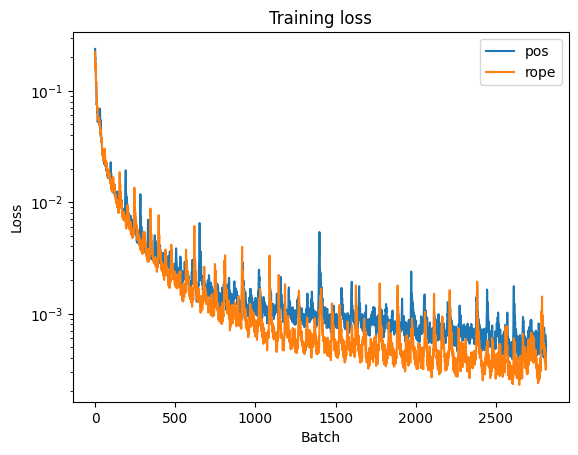

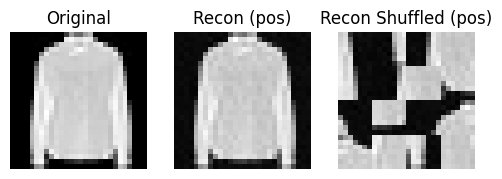

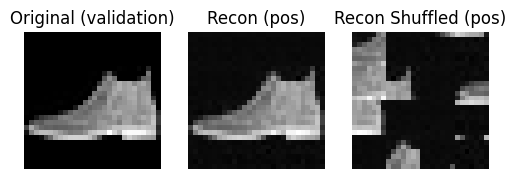

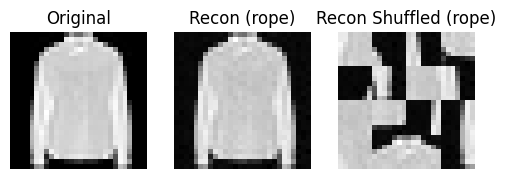

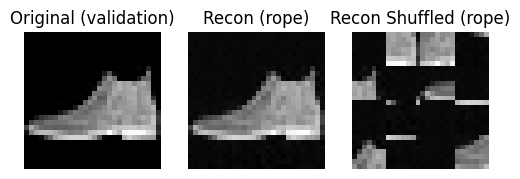

In [98]:
# Plot history loss
plt.figure()
plt.plot(loss_history_pos, label="pos")
plt.plot(loss_history_rope, label="rope")
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.yscale("log")
plt.title("Training loss")
plt.legend()
print("min loss pos = ", min(loss_history_pos))
print("min loss rope = ", min(loss_history_rope))

# Plot a recon and compare to original
images, labels = next(iter(train_loader))
model_pos.eval()
model_rope.eval()
recons_pos, _ = model_pos(images.to(device))
print("recon loss on shown training recon (pos) = ", F.mse_loss(images[0].to(device), recons_pos[0]).item())
print("recon loss on training recon batch (pos) = ", F.mse_loss(images.to(device), recons_pos).item())
recons_rope, _ = model_rope(images.to(device))
print("recon loss on shown training recon (rope) = ", F.mse_loss(images[0].to(device), recons_rope[0]).item())
print("recon loss on training recon batch (rope) = ", F.mse_loss(images.to(device), recons_rope).item())

# Shuffle patches and run a forward pass through ViT model
perm = torch.randperm(model_pos.grid_size**2)
image_patches = patchify(images.to(device), model_pos.patch_size)
z = model_pos.encoder(image_patches[:, perm])
seq = model_pos.decoder(z)
recons_shuffled_pos = unpatchify(seq, model_pos.patch_size, model_pos.grid_size)

perm = torch.randperm(model_rope.grid_size**2)
image_patches = patchify(images.to(device), model_rope.patch_size)
z = model_rope.encoder(image_patches[:, perm])
seq = model_rope.decoder(z)
recons_shuffled_rope = unpatchify(seq, model_rope.patch_size, model_rope.grid_size )


# Plot a recon and compare to original
images_val, labels_val = next(iter(test_loader))
recons_val_pos, _ = model_pos(images_val.to(device))
print("recon loss on shown validation recon (pos) = ", F.mse_loss(images_val[0].to(device), recons_val_pos[0]).item())
print("recon loss on validation recon batch (pos) = ", F.mse_loss(images_val.to(device), recons_val_pos).item())
recons_val_rope, _ = model_rope(images_val.to(device))
print("recon loss on shown validation recon (rope) = ", F.mse_loss(images_val[0].to(device), recons_val_rope[0]).item())
print("recon loss on validation recon batch (rope) = ", F.mse_loss(images_val.to(device), recons_val_rope).item())

# Shuffle patches and run a forward pass through ViT model
perm = torch.randperm(model_pos.grid_size**2)
image_patches = patchify(images_val.to(device), model_pos.patch_size)
z = model_pos.encoder(image_patches[:, perm])
seq = model_pos.decoder(z)
recons_val_shuffled_pos = unpatchify(seq, model_pos.patch_size, model_pos.grid_size )

perm = torch.randperm(model_rope.grid_size**2)
image_patches = patchify(images_val.to(device), model_rope.patch_size)
z = model_rope.encoder(image_patches[:, perm])
seq = model_rope.decoder(z)
recons_val_shuffled_rope = unpatchify(seq, model_rope.patch_size, model_rope.grid_size )


fig, ax = plt.subplots(1, 3, figsize=(6, 3))
ax[0].imshow(images[0][0].cpu().numpy(), cmap="gray")
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(recons_pos[0][0].detach().cpu().numpy(), cmap="gray")
ax[1].set_title("Recon (pos)")
ax[1].axis("off")

ax[2].imshow(recons_shuffled_pos[0][0].detach().cpu().numpy(), cmap="gray")
ax[2].set_title("Recon Shuffled (pos)")
ax[2].axis("off")

plt.show()

fig, ax = plt.subplots(1, 3, figsize=(6, 3))
ax[0].imshow(images_val[0][0].cpu().numpy(), cmap="gray")
ax[0].set_title("Original (validation)")
ax[0].axis("off")

ax[1].imshow(recons_val_pos[0][0].detach().cpu().numpy(), cmap="gray")
ax[1].set_title("Recon (pos)")
ax[1].axis("off")


ax[2].imshow(recons_val_shuffled_pos[0][0].detach().cpu().numpy(), cmap="gray")
ax[2].set_title("Recon Shuffled (pos)")
ax[2].axis("off")

plt.show()


fig, ax = plt.subplots(1, 3, figsize=(6, 3))
ax[0].imshow(images[0][0].cpu().numpy(), cmap="gray")
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(recons_rope[0][0].detach().cpu().numpy(), cmap="gray")
ax[1].set_title("Recon (rope)")
ax[1].axis("off")

ax[2].imshow(recons_shuffled_rope[0][0].detach().cpu().numpy(), cmap="gray")
ax[2].set_title("Recon Shuffled (rope)")
ax[2].axis("off")

plt.show()

fig, ax = plt.subplots(1, 3, figsize=(6, 3))
ax[0].imshow(images_val[0][0].cpu().numpy(), cmap="gray")
ax[0].set_title("Original (validation)")
ax[0].axis("off")

ax[1].imshow(recons_val_rope[0][0].detach().cpu().numpy(), cmap="gray")
ax[1].set_title("Recon (rope)")
ax[1].axis("off")


ax[2].imshow(recons_val_shuffled_rope[0][0].detach().cpu().numpy(), cmap="gray")
ax[2].set_title("Recon Shuffled (rope)")
ax[2].axis("off")

plt.show()


# # Visualize attention 
# enc = model_pos.encoder
# x = enc.ff(patchify(images.to(device), 7)) + enc.pos   # trained embed + pos
# blk = enc.attn_blocks[1]
# _, w = blk.attention(blk.layer_norm1(x)) # trained weights (B, num_heads, grid_size**2, 512/num_head)

# grid_size = int((dim//n_heads)**0.5)
# q=1

# for head in range(4):
#     # which patch is "looking"
#     # heat = w[0, head, q].reshape(grid, grid)   # (4,4): where patch q attends
#     heat = einops.rearrange(w[0, head, q], "(g1 g2) ->  g1 g2", g1=grid_size)
#     img = images[0][0]
#     plt.figure()
#     plt.imshow(img.cpu(), cmap="gray")
#     plt.imshow(heat.cpu().detach(), alpha=.5, extent=[0,28,28,0], cmap="hot")  # upsamples 4×4 over the image

#     print(w.shape)
    
    
# enc = model_rope.encoder
# x = enc.ff(patchify(images.to(device), 7))   # trained embed + pos
# blk = enc.attn_blocks[1]
# _, w = blk.attention(blk.layer_norm1(x)) # trained weights (B, num_heads, grid_size**2, 512/num_head)

# grid_size = int((dim//n_heads)**0.5)
# q=1

# for head in range(4):
#     # which patch is "looking"
#     # heat = w[0, head, q].reshape(grid, grid)   # (4,4): where patch q attends
#     heat = einops.rearrange(w[0, head, q], "(g1 g2) ->  g1 g2", g1=grid_size)
#     img = images[0][0]
#     plt.figure()
#     plt.imshow(img.cpu(), cmap="gray")
#     plt.imshow(heat.cpu().detach(), alpha=.5, extent=[0,28,28,0], cmap="hot")  # upsamples 4×4 over the image

#     print(w.shape)
    



min loss pos =  0.0002770325809251517
min loss rope =  0.00029177640681155026
recon loss on shown training recon (pos) =  0.00019895288278348744
recon loss on training recon batch (pos) =  0.0004820898757316172
recon loss on shown training recon (rope) =  0.00014969274343457073
recon loss on training recon batch (rope) =  0.000492340768687427
recon loss on shown validation recon (pos) =  0.0002544039161875844
recon loss on validation recon batch (pos) =  0.00040403829189017415
recon loss on shown validation recon (rope) =  0.00018707700655795634
recon loss on validation recon batch (rope) =  0.00035065534757450223


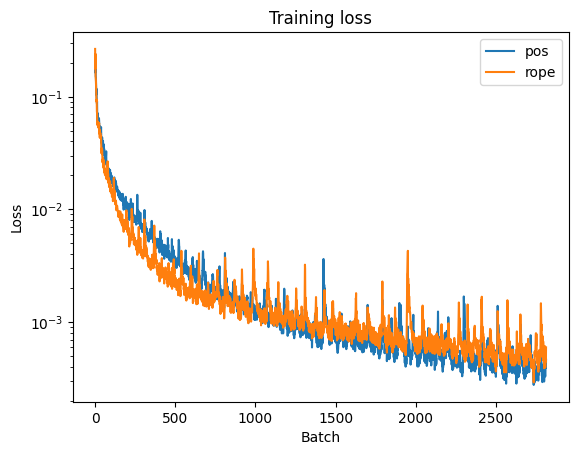

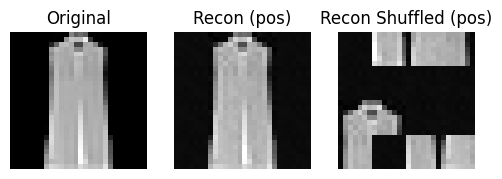

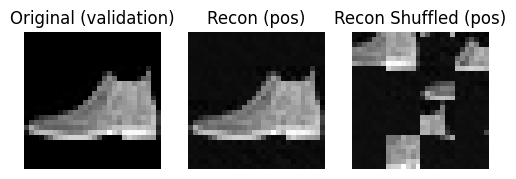

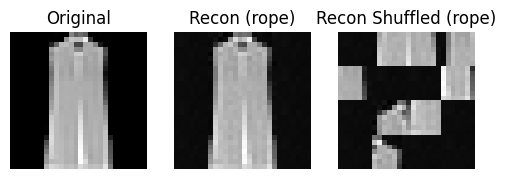

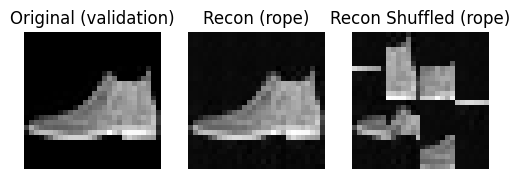

In [87]:
# Plot history loss
plt.figure()
plt.plot(loss_history_pos, label="pos")
plt.plot(loss_history_rope, label="rope")
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.yscale("log")
plt.title("Training loss")
plt.legend()
print("min loss pos = ", min(loss_history_pos))
print("min loss rope = ", min(loss_history_rope))

# Plot a recon and compare to original
images, labels = next(iter(train_loader))
model_pos.eval()
model_rope.eval()
recons_pos, _ = model_pos(images.to(device))
print("recon loss on shown training recon (pos) = ", F.mse_loss(images[0].to(device), recons_pos[0]).item())
print("recon loss on training recon batch (pos) = ", F.mse_loss(images.to(device), recons_pos).item())
recons_rope, _ = model_rope(images.to(device))
print("recon loss on shown training recon (rope) = ", F.mse_loss(images[0].to(device), recons_rope[0]).item())
print("recon loss on training recon batch (rope) = ", F.mse_loss(images.to(device), recons_rope).item())

# Shuffle patches and run a forward pass through ViT model
perm = torch.randperm(model_pos.grid_size**2)
image_patches = patchify(images.to(device), model_pos.patch_size)
z = model_pos.encoder(image_patches[:, perm])
seq = model_pos.decoder(z)
recons_shuffled_pos = unpatchify(seq, model_pos.patch_size, model_pos.grid_size)

perm = torch.randperm(model_rope.grid_size**2)
image_patches = patchify(images.to(device), model_rope.patch_size)
z = model_rope.encoder(image_patches[:, perm])
seq = model_rope.decoder(z)
recons_shuffled_rope = unpatchify(seq, model_rope.patch_size, model_rope.grid_size )


# Plot a recon and compare to original
images_val, labels_val = next(iter(test_loader))
recons_val_pos, _ = model_pos(images_val.to(device))
print("recon loss on shown validation recon (pos) = ", F.mse_loss(images_val[0].to(device), recons_val_pos[0]).item())
print("recon loss on validation recon batch (pos) = ", F.mse_loss(images_val.to(device), recons_val_pos).item())
recons_val_rope, _ = model_rope(images_val.to(device))
print("recon loss on shown validation recon (rope) = ", F.mse_loss(images_val[0].to(device), recons_val_rope[0]).item())
print("recon loss on validation recon batch (rope) = ", F.mse_loss(images_val.to(device), recons_val_rope).item())

# Shuffle patches and run a forward pass through ViT model
perm = torch.randperm(model_pos.grid_size**2)
image_patches = patchify(images_val.to(device), model_pos.patch_size)
z = model_pos.encoder(image_patches[:, perm])
seq = model_pos.decoder(z)
recons_val_shuffled_pos = unpatchify(seq, model_pos.patch_size, model_pos.grid_size )

perm = torch.randperm(model_rope.grid_size**2)
image_patches = patchify(images_val.to(device), model_rope.patch_size)
z = model_rope.encoder(image_patches[:, perm])
seq = model_rope.decoder(z)
recons_val_shuffled_rope = unpatchify(seq, model_rope.patch_size, model_rope.grid_size )


fig, ax = plt.subplots(1, 3, figsize=(6, 3))
ax[0].imshow(images[0][0].cpu().numpy(), cmap="gray")
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(recons_pos[0][0].detach().cpu().numpy(), cmap="gray")
ax[1].set_title("Recon (pos)")
ax[1].axis("off")

ax[2].imshow(recons_shuffled_pos[0][0].detach().cpu().numpy(), cmap="gray")
ax[2].set_title("Recon Shuffled (pos)")
ax[2].axis("off")

plt.show()

fig, ax = plt.subplots(1, 3, figsize=(6, 3))
ax[0].imshow(images_val[0][0].cpu().numpy(), cmap="gray")
ax[0].set_title("Original (validation)")
ax[0].axis("off")

ax[1].imshow(recons_val_pos[0][0].detach().cpu().numpy(), cmap="gray")
ax[1].set_title("Recon (pos)")
ax[1].axis("off")


ax[2].imshow(recons_val_shuffled_pos[0][0].detach().cpu().numpy(), cmap="gray")
ax[2].set_title("Recon Shuffled (pos)")
ax[2].axis("off")

plt.show()


fig, ax = plt.subplots(1, 3, figsize=(6, 3))
ax[0].imshow(images[0][0].cpu().numpy(), cmap="gray")
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(recons_rope[0][0].detach().cpu().numpy(), cmap="gray")
ax[1].set_title("Recon (rope)")
ax[1].axis("off")

ax[2].imshow(recons_shuffled_rope[0][0].detach().cpu().numpy(), cmap="gray")
ax[2].set_title("Recon Shuffled (rope)")
ax[2].axis("off")

plt.show()

fig, ax = plt.subplots(1, 3, figsize=(6, 3))
ax[0].imshow(images_val[0][0].cpu().numpy(), cmap="gray")
ax[0].set_title("Original (validation)")
ax[0].axis("off")

ax[1].imshow(recons_val_rope[0][0].detach().cpu().numpy(), cmap="gray")
ax[1].set_title("Recon (rope)")
ax[1].axis("off")


ax[2].imshow(recons_val_shuffled_rope[0][0].detach().cpu().numpy(), cmap="gray")
ax[2].set_title("Recon Shuffled (rope)")
ax[2].axis("off")

plt.show()


# # Visualize attention 
# enc = model_pos.encoder
# x = enc.ff(patchify(images.to(device), 7)) + enc.pos   # trained embed + pos
# blk = enc.attn_blocks[1]
# _, w = blk.attention(blk.layer_norm1(x)) # trained weights (B, num_heads, grid_size**2, 512/num_head)

# grid_size = int((dim//n_heads)**0.5)
# q=1

# for head in range(4):
#     # which patch is "looking"
#     # heat = w[0, head, q].reshape(grid, grid)   # (4,4): where patch q attends
#     heat = einops.rearrange(w[0, head, q], "(g1 g2) ->  g1 g2", g1=grid_size)
#     img = images[0][0]
#     plt.figure()
#     plt.imshow(img.cpu(), cmap="gray")
#     plt.imshow(heat.cpu().detach(), alpha=.5, extent=[0,28,28,0], cmap="hot")  # upsamples 4×4 over the image

#     print(w.shape)
    
    
# enc = model_rope.encoder
# x = enc.ff(patchify(images.to(device), 7))   # trained embed + pos
# blk = enc.attn_blocks[1]
# _, w = blk.attention(blk.layer_norm1(x)) # trained weights (B, num_heads, grid_size**2, 512/num_head)

# grid_size = int((dim//n_heads)**0.5)
# q=1

# for head in range(4):
#     # which patch is "looking"
#     # heat = w[0, head, q].reshape(grid, grid)   # (4,4): where patch q attends
#     heat = einops.rearrange(w[0, head, q], "(g1 g2) ->  g1 g2", g1=grid_size)
#     img = images[0][0]
#     plt.figure()
#     plt.imshow(img.cpu(), cmap="gray")
#     plt.imshow(heat.cpu().detach(), alpha=.5, extent=[0,28,28,0], cmap="hot")  # upsamples 4×4 over the image

#     print(w.shape)
    



## 2. Gaussian NLL Head
We used MSE, which punishes model for predicting the pixel being very far from actual pixel. However, it doesn't take into account uncertainty in its prediction. It basically says "I am equally confident about every pixel prediction".

This is similar to minimize Gaussian likelhood where sigma, σ, (or the likelihood) is a constant set to 1. So σ=1. But if sigma is not constant, it can say "I am less confident about this prediction" for example.

However, the model can cheat so it requires some finetuning. For example, the model can reduce punishment for its bad prediction simply by saying "OOPs, I am very uncertain my bad". The "log" log(sigma) prevents infinite uncertainty, but still need to be careful. Also, now we need to train for two things, how good the prediction is, and how good the certainty in the prediction is. If a model is 95% sure, but is only correct 60% of the time, it is bad. So reason we don't always use it is because it isn't always good.

The Gaussian negative log-likelihood is:
(x−μ)^2 / 2σ^2 ​ +log(σ)

That being said, predicting uncertainty PER PIXEL is not enough to create sharper images. If a model sees an ambiguous pixel, the uncertainty per pixel just tells us this pixel is ambiguous. What we want is uncertainty in larger visual structures. 


In [ ]:
class AttnBlock(nn.Module):
    def __init__(self, dim: int, n_heads: int, use_pos: bool = False, attn_multiple: int = 4):
        super().__init__()
        self.attention = MHA_RoPE(dim, n_heads, use_rope=not use_pos)
        self.layer_norm1 = nn.LayerNorm(dim)
        self.layer_norm2 = nn.LayerNorm(dim)
        self.ff = nn.Sequential(
            nn.Linear(dim, attn_multiple * dim),
            nn.GELU(),
            nn.Linear(attn_multiple * dim, dim)
        )        
                    
    def forward(self, x):
        # attending to tokens across patches with a residual
        out, _ = self.attention(self.layer_norm1(x))
        x = x + out
        
        # channel mixing per token - a "scratch space" to make sense of the tokens we attended to
        out = self.ff(self.layer_norm2(x))
        x = x + out
        
        return x
        

class ViT_Encoder(nn.Module):
    def __init__(self, dim: int, n_heads: int, z_dim: int, P: int, N: int, use_pos: bool, k: int = 2):
        super().__init__()
        
        self.ff = nn.Sequential(nn.Linear(P, dim), nn.GELU())
                
        # Stack attention blocks
        self.attn_blocks = nn.Sequential(*[AttnBlock(dim, n_heads, use_pos=use_pos) for i in range(k)])
        
        # Linear layer to encode to a lower dim (not sure if we should use GELU here or not)
        self.ff2 = nn.Sequential(nn.GELU(), nn.Linear(dim, z_dim))
                        
        # Layer for positional encoding
        self.pos = nn.Parameter(torch.randn(1, N, dim) * 0.02) # N = grid_size ** 2
        self.use_pos = use_pos
        
        
    def forward(self, seq):
        """
        Args:
            seq (B, N, P) P is patch_size**2 and N is number of patches rows x coloumns
            
        Returns:
            z (B, N, z_dim)
        """
        # embed sequence
        x = self.ff(seq)   
        
        # positional encoding             
        if self.use_pos:
            x = x + self.pos
        
        # Attention block
        x = self.attn_blocks(x)
        
        # project sequence to comrpessed latent vector
        z = self.ff2(x)
        return z
    
    
class ViT_DecoderGaussian(nn.Module):
    def __init__(self, dim: int, n_heads: int, z_dim: int, P: int, N: int, use_pos: bool, k: int = 2):
        super().__init__()
        
        # Linear layer to decode from a lower dim to a higher one (not sure if we should use GELU here or not)
        self.ff = nn.Sequential(nn.GELU(), nn.Linear(z_dim, dim))
        
        # Stack attention blocks
        self.attn_blocks = nn.Sequential(*[AttnBlock(dim, n_heads, use_pos=use_pos) for i in range(k)])
        
        # Linear layer to unembed tokens. Linear shouldn't end with an activation function since we want raw pixel values (basic ML stuff)
        self.ff2 = nn.Sequential(nn.GELU(), nn.Linear(dim, P*2)) # *2 for outputting pixel prediction AND uncertainty sigma
        
        # Layer for positional encoding
        self.pos = nn.Parameter(torch.randn(1, N, dim) * 0.02) # N = grid_size ** 2
        self.use_pos = use_pos

    def forward(self, seq):
        """
        Args:
            seq (B, N, z_dim): latent vector encoded via ViT_Encoder
            
        Returns:
            out (B, N, P*2) P is patch_size**2 and N is number of patches rows x coloumns
        """
        # embed sequence
        x = self.ff(seq)
        
        # positional encoding             
        if self.use_pos:
            x = x + self.pos
            
        x = self.attn_blocks(x)
        
        # project sequence to uncompressed seq
        x = self.ff2(x)
        
        # Split into mean (average predictions) and logvar (uncertainty in prediction)
        # we don't train sigma^2 to keep it positive and table when we apply it.
        x_mean, x_logvar = x.chunk(2, dim=-1)
        x_logvar = torch.clamp(x_logvar, -7, 7) # for stability ensuring min var is exp(-7) ~ 1e-3 or exp(7)~1e3 It did MUCH worse without clamping on FashionMNIST
        
        return x_mean, x_logvar


class ViT_AutoEncoderGaussian(nn.Module):
    def __init__(self, dim: int, n_heads: int, z_dim: int, patch_size: int, grid_size: int, k: int = 2, use_pos=False):
        super().__init__()
        
        self.patch_size = patch_size
        self.grid_size = grid_size
        
        self.encoder = ViT_Encoder(dim, n_heads, z_dim, patch_size**2, grid_size**2, use_pos=use_pos, k=k)
        self.decoder = ViT_DecoderGaussian(dim, n_heads, z_dim, patch_size**2, grid_size**2, use_pos=use_pos, k=k)


    def forward(self, images):
        """
        Args:
            images (B, C, H, W)
        """
        image_patches = patchify(images, self.patch_size)
        z = self.encoder(image_patches)
        x_mean, x_logvar = self.decoder(z)
        recon = unpatchify(x_mean, self.patch_size, self.grid_size)
        
        return recon, x_mean, x_logvar, z

    
    
# --- Training Loop ---
# define hyperparams
epochs = 3
dim = 64
n_heads = 4
z_dim = 16
patch_size = 7
grid_size = int(next(iter(train_loader))[0].shape[-1] // patch_size)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# define model
model_gauss = ViT_AutoEncoderGaussian(dim, n_heads, z_dim, patch_size, grid_size, use_pos=False).to(device)
model_rope = ViT_AutoEncoder(dim, n_heads, z_dim, patch_size, grid_size, use_pos=False).to(device)

# setup optimizer
optimizer_gauss = torch.optim.AdamW(model_gauss.parameters(), lr=3e-4)
optimizer_rope = torch.optim.AdamW(model_rope.parameters(), lr=3e-4)

# define tracking lists
loss_history_gauss = []
loss_history_rope = []

# training loop
for epoch in tqdm(range(epochs)):
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
    
    for images, labels in pbar:
        images = images.to(device)
        image_patches = patchify(images, patch_size).to(device)

        # 1. run forward pass through model
        recon_gauss, mean, logvar, z_pos = model_gauss(images)
        recon_rope, z_rope = model_rope(images)
        
        # 2. calculate loss
        loss_gauss = 0.5 * ((image_patches - mean).pow(2) * (torch.exp(-logvar)) + logvar)
        loss_gauss = loss_gauss.mean()
        # Or you can do loss_gauss = F.gaussian_nll_loss(mean, image_patches, torch.exp(logvar))        
        loss_rope = F.mse_loss(recon_rope, images)
        
        # 3. backprop and update weights
        optimizer_gauss.zero_grad()
        loss_gauss.backward()
        optimizer_gauss.step()
        optimizer_rope.zero_grad()
        loss_rope.backward()
        optimizer_rope.step()
        
        # Show live loss
        pbar.set_postfix(loss=loss_rope.item())
        
        # Track loss
        loss_rope_mse = F.mse_loss(recon_gauss, images)
        loss_history_gauss.append(loss_rope_mse.item())
        loss_history_rope.append(loss_rope.item())
        
        
                

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 1/3:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 2/3:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 3/3:   0%|          | 0/938 [00:00<?, ?it/s]

min loss gauss =  0.0073631987906992435
min loss rope =  0.004377565812319517
recon loss on shown training recon (gauss) =  0.004651425871998072
recon loss on training recon batch (gauss) =  0.008318400010466576
recon loss on shown training recon (rope) =  0.0027562775649130344
recon loss on training recon batch (rope) =  0.005195947363972664
recon loss on shown validation recon (gauss) =  0.004802645184099674
recon loss on validation recon batch (gauss) =  0.008041399531066418
recon loss on shown validation recon (rope) =  0.0025626658461987972
recon loss on validation recon batch (rope) =  0.004778382368385792


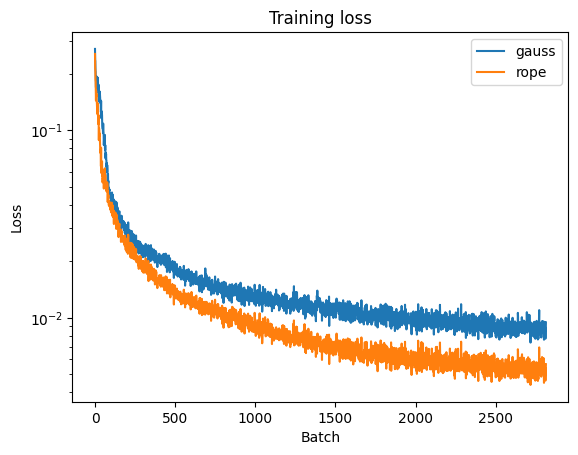

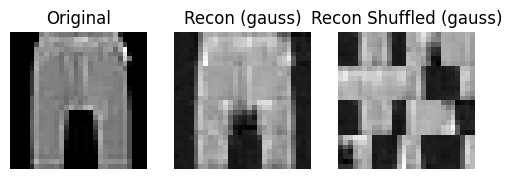

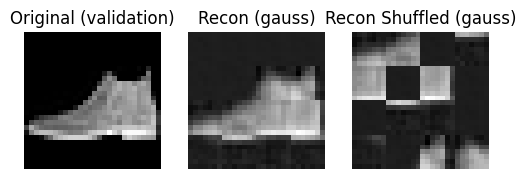

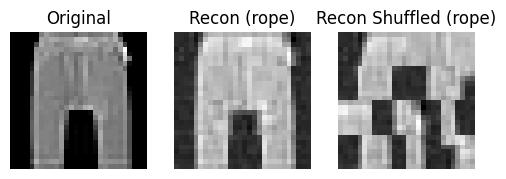

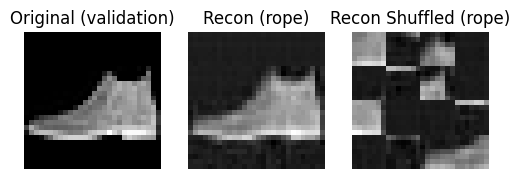

In [172]:
# Plot history loss
plt.figure()
plt.plot(loss_history_gauss, label="gauss")
plt.plot(loss_history_rope, label="rope")
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.yscale("log")
plt.title("Training loss")
plt.legend()
print("min loss gauss = ", min(loss_history_gauss))
print("min loss rope = ", min(loss_history_rope))

# Plot a recon and compare to original
images, labels = next(iter(train_loader))
model_gauss.eval()
model_rope.eval()
recons_gauss, _, _, _ = model_gauss(images.to(device))
print("recon loss on shown training recon (gauss) = ", F.mse_loss(images[0].to(device), recons_gauss[0]).item())
print("recon loss on training recon batch (gauss) = ", F.mse_loss(images.to(device), recons_gauss).item())
recons_rope, _ = model_rope(images.to(device))
print("recon loss on shown training recon (rope) = ", F.mse_loss(images[0].to(device), recons_rope[0]).item())
print("recon loss on training recon batch (rope) = ", F.mse_loss(images.to(device), recons_rope).item())

# Shuffle patches and run a forward pass through ViT model
perm = torch.randperm(model_gauss.grid_size**2)
image_patches = patchify(images.to(device), model_gauss.patch_size)
z = model_gauss.encoder(image_patches[:, perm])
seq, _ = model_gauss.decoder(z)
recons_shuffled_gauss = unpatchify(seq, model_gauss.patch_size, model_gauss.grid_size)

perm = torch.randperm(model_rope.grid_size**2)
image_patches = patchify(images.to(device), model_rope.patch_size)
z = model_rope.encoder(image_patches[:, perm])
seq = model_rope.decoder(z)
recons_shuffled_rope = unpatchify(seq, model_rope.patch_size, model_rope.grid_size )


# Plot a recon and compare to original
images_val, labels_val = next(iter(test_loader))
recons_val_gauss, _, logvar, _ = model_gauss(images_val.to(device))
print("recon loss on shown validation recon (gauss) = ", F.mse_loss(images_val[0].to(device), recons_val_gauss[0]).item())
print("recon loss on validation recon batch (gauss) = ", F.mse_loss(images_val.to(device), recons_val_gauss).item())
recons_val_rope, _ = model_rope(images_val.to(device))
print("recon loss on shown validation recon (rope) = ", F.mse_loss(images_val[0].to(device), recons_val_rope[0]).item())
print("recon loss on validation recon batch (rope) = ", F.mse_loss(images_val.to(device), recons_val_rope).item())

# Shuffle patches and run a forward pass through ViT model
perm = torch.randperm(model_gauss.grid_size**2)
image_patches = patchify(images_val.to(device), model_gauss.patch_size)
z = model_gauss.encoder(image_patches[:, perm])
seq, _ = model_gauss.decoder(z)
recons_val_shuffled_gauss = unpatchify(seq, model_gauss.patch_size, model_gauss.grid_size )

perm = torch.randperm(model_rope.grid_size**2)
image_patches = patchify(images_val.to(device), model_rope.patch_size)
z = model_rope.encoder(image_patches[:, perm])
seq = model_rope.decoder(z)
recons_val_shuffled_rope = unpatchify(seq, model_rope.patch_size, model_rope.grid_size )


fig, ax = plt.subplots(1, 3, figsize=(6, 3))
ax[0].imshow(images[0][0].cpu().numpy(), cmap="gray")
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(recons_gauss[0][0].detach().cpu().numpy(), cmap="gray")
ax[1].set_title("Recon (gauss)")
ax[1].axis("off")

ax[2].imshow(recons_shuffled_gauss[0][0].detach().cpu().numpy(), cmap="gray")
ax[2].set_title("Recon Shuffled (gauss)")
ax[2].axis("off")

plt.show()

fig, ax = plt.subplots(1, 3, figsize=(6, 3))
ax[0].imshow(images_val[0][0].cpu().numpy(), cmap="gray")
ax[0].set_title("Original (validation)")
ax[0].axis("off")

ax[1].imshow(recons_val_gauss[0][0].detach().cpu().numpy(), cmap="gray")
ax[1].set_title("Recon (gauss)")
ax[1].axis("off")


ax[2].imshow(recons_val_shuffled_gauss[0][0].detach().cpu().numpy(), cmap="gray")
ax[2].set_title("Recon Shuffled (gauss)")
ax[2].axis("off")

plt.show()


fig, ax = plt.subplots(1, 3, figsize=(6, 3))
ax[0].imshow(images[0][0].cpu().numpy(), cmap="gray")
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(recons_rope[0][0].detach().cpu().numpy(), cmap="gray")
ax[1].set_title("Recon (rope)")
ax[1].axis("off")

ax[2].imshow(recons_shuffled_rope[0][0].detach().cpu().numpy(), cmap="gray")
ax[2].set_title("Recon Shuffled (rope)")
ax[2].axis("off")

plt.show()

fig, ax = plt.subplots(1, 3, figsize=(6, 3))
ax[0].imshow(images_val[0][0].cpu().numpy(), cmap="gray")
ax[0].set_title("Original (validation)")
ax[0].axis("off")

ax[1].imshow(recons_val_rope[0][0].detach().cpu().numpy(), cmap="gray")
ax[1].set_title("Recon (rope)")
ax[1].axis("off")


ax[2].imshow(recons_val_shuffled_rope[0][0].detach().cpu().numpy(), cmap="gray")
ax[2].set_title("Recon Shuffled (rope)")
ax[2].axis("off")

plt.show()





Here we plot uncertainty

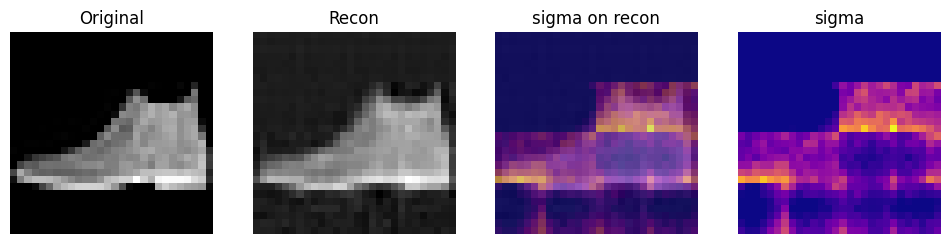

In [173]:
# Plot uncertaint map overlayed on top of reconstruction
recons_val_gauss, _, logvar, _ = model_gauss(images_val.to(device))

sigma = torch.exp(0.5*logvar)
# sigma_map = einops.rearrange(sigma[0], "(g1 g2) (p1 p2) ->  (g1 p1) (g2 p2)", g1=grid_size, p1=patch_size)
sigma_map = unpatchify(sigma, patch_size, grid_size)

fig, ax = plt.subplots(1, 4, figsize=(12, 6))
ax[0].imshow(images_val[0][0].cpu().numpy(), cmap="gray")
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(recons_val_rope[0][0].detach().cpu().numpy(), cmap="gray")
ax[1].set_title("Recon")
ax[1].axis("off")

ax[2].imshow(recons_val_rope[0][0].detach().cpu().numpy(), cmap="gray")
ax[2].imshow(sigma_map[0][0].cpu().detach(), alpha=.6, cmap="plasma")  # upsamples 4×4 over the image
ax[2].set_title("sigma on recon")
ax[2].axis("off")

ax[3].imshow(sigma_map[0][0].cpu().detach(), alpha=1, cmap="plasma")  # upsamples 4×4 over the image
ax[3].set_title("sigma")
ax[3].axis("off")

plt.show()

### 2.2 Categorical loss
We tried gaussian, it was good with larger models honestly. with lower dims though, it is kinda blurry. 

One way to solve this is to divide range of possible answers into fixed bins. The decoder outputs K scores per pixel instead of a logvar distribution. We train with cross entropy loss against the correct bin instead of negative log-likelihood.

So instead of predicting a continuous value, we predict a probability distribution over brightness levels. The problem with gaussian is that it has one peak (it is not a mixture of gaussians). 
We need to sample from a distribution with multiple possible outcomes rather than sampling from a distribution with a single possible outcome. Now this isn't a continuous mixture of gaussians. Instead, it is discretized into bins to make it easier for model to predict.


In [218]:
class ViT_DecoderCategorical(nn.Module):
    def __init__(self, dim: int, n_heads: int, z_dim: int, P: int, N: int, num_bins: int, use_pos: bool, k: int = 2):
        super().__init__()
        
        # Linear layer to decode from a lower dim to a higher one (not sure if we should use GELU here or not)
        self.ff = nn.Sequential(nn.GELU(), nn.Linear(z_dim, dim))
        
        # Stack attention blocks
        self.attn_blocks = nn.Sequential(*[AttnBlock(dim, n_heads, use_pos=use_pos) for i in range(k)])
        
        # Linear layer to unembed tokens. Linear shouldn't end with an activation function since we want raw pixel values (basic ML stuff)
        self.ff2 = nn.Sequential(nn.GELU(), nn.Linear(dim, P * num_bins)) # we multiple by num of bins
        self.num_bins = num_bins
        
        # Layer for positional encoding
        self.pos = nn.Parameter(torch.randn(1, N, dim) * 0.02) # N = grid_size ** 2
        self.use_pos = use_pos

    def forward(self, seq):
        """
        Args:
            seq (B, N, z_dim): latent vector encoded via ViT_Encoder
            
        Returns:
            logits (B, N, P, num_bins) logits for cross entropy loss
        """
        # embed sequence
        x = self.ff(seq)
        
        # positional encoding             
        if self.use_pos:
            x = x + self.pos
            
        x = self.attn_blocks(x)
        
        # project sequence to uncompressed seq
        x = self.ff2(x)
        
        # reshape x to get num of bins
        logits = einops.rearrange(x, "b n (p k) -> b n p k", k=self.num_bins)
        
        # # Sample logits by taking bin with the max value
        # x_sample = logits.argmax(dim=-1)  # (B, N, P)
        # x_sample = x_sample.float() / (self.num_bins - 1)  # resample int bins from 0,1,2,... to a domain between 0 and 1
        
        # # OR sample logits according to their probability (e.g. bin 1 has 40% chance of being sampled, bin 2 has 60% chance. bin 1 still can get sampled, even if lower bin value)
        distribution = torch.distributions.Categorical(logits=logits)
        x_sample = distribution.sample().float() / (self.num_bins - 1)
        
        return logits, x_sample


class ViT_AutoEncoderCategorical(nn.Module):
    def __init__(self, dim: int, n_heads: int, z_dim: int, patch_size: int, grid_size: int, num_bins: int, k: int = 2, use_pos=False):
        super().__init__()
        
        self.patch_size = patch_size
        self.grid_size = grid_size
        self.num_bins = num_bins
        
        self.encoder = ViT_Encoder(dim, n_heads, z_dim, patch_size**2, grid_size**2, use_pos=use_pos, k=k)
        self.decoder = ViT_DecoderCategorical(dim, n_heads, z_dim, patch_size**2, grid_size**2, num_bins, use_pos=use_pos, k=k)


    def forward(self, images):
        """
        Args:
            images (B, C, H, W)
        """
        image_patches = patchify(images, self.patch_size)
        z = self.encoder(image_patches)
        logits, x_sample = self.decoder(z) # (B, N, P, num_bins)
        recon = unpatchify(x_sample, self.patch_size, self.grid_size)
        
        return recon, x_sample, logits

    
    
# --- Training Loop ---
# define hyperparams
epochs = 3
dim = 512
n_heads = 8
z_dim = 64
patch_size = 7
num_bins = 32
grid_size = int(next(iter(train_loader))[0].shape[-1] // patch_size)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# define model
model_gauss = ViT_AutoEncoderGaussian(dim, n_heads, z_dim, patch_size, grid_size, use_pos=False).to(device)
model_categorical = ViT_AutoEncoderCategorical(dim, n_heads, z_dim, patch_size, grid_size, num_bins, use_pos=False).to(device)

# setup optimizer
optimizer_gauss = torch.optim.AdamW(model_gauss.parameters(), lr=3e-4)
optimizer_categorical = torch.optim.AdamW(model_categorical.parameters(), lr=3e-4)

# define tracking lists
loss_history_gauss = []
loss_history_categorical = []

# training loop
for epoch in tqdm(range(epochs)):
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
    
    for images, labels in pbar:
        images = images.to(device)
        image_patches = patchify(images, patch_size).to(device)
        # Quantize the target
        image_patches_bins = (image_patches * (num_bins - 1)).round().long()

        # 1. run forward pass through model
        recon_gauss, mean, logvar, z_pos = model_gauss(images)
        recon_categorical, _, logits = model_categorical(images)
        
        # 2. calculate loss
        loss_gauss = 0.5 * ((image_patches - mean).pow(2) * (torch.exp(-logvar)) + logvar)
        loss_gauss = loss_gauss.mean()
        # Or you can do loss_gauss = F.gaussian_nll_loss(mean, image_patches, torch.exp(logvar))        
        loss_categorical = F.cross_entropy(logits.reshape(-1, num_bins), image_patches_bins.reshape(-1))
        
        # 3. backprop and update weights
        optimizer_gauss.zero_grad()
        loss_gauss.backward()
        optimizer_gauss.step()
        optimizer_categorical.zero_grad()
        loss_categorical.backward()
        optimizer_categorical.step()
        
        # Show live loss
        pbar.set_postfix(loss=loss_categorical.item())
        
        # Track loss
        loss_gauss_mse = F.mse_loss(recon_gauss, images)
        loss_categorical_mse = F.mse_loss(recon_categorical, images)
        loss_history_gauss.append(loss_gauss_mse.item())
        loss_history_categorical.append(loss_categorical_mse.item())
        
        
                

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 1/3:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 2/3:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 3/3:   0%|          | 0/938 [00:00<?, ?it/s]

min loss gauss =  6.112738628871739e-05
min loss categorical =  0.005302321631461382
recon loss on shown training recon (gauss) =  0.00014193032984621823
recon loss on training recon batch (gauss) =  0.00015778910892549902
recon loss on shown training recon (categorical) =  0.008937764912843704
recon loss on training recon batch (categorical) =  0.006243251264095306
recon loss on shown validation recon (gauss) =  8.666927897138521e-05
recon loss on validation recon batch (gauss) =  0.0001560310338390991
recon loss on shown validation recon (categorical) =  0.0027135470882058144
recon loss on validation recon batch (categorical) =  0.006190379150211811


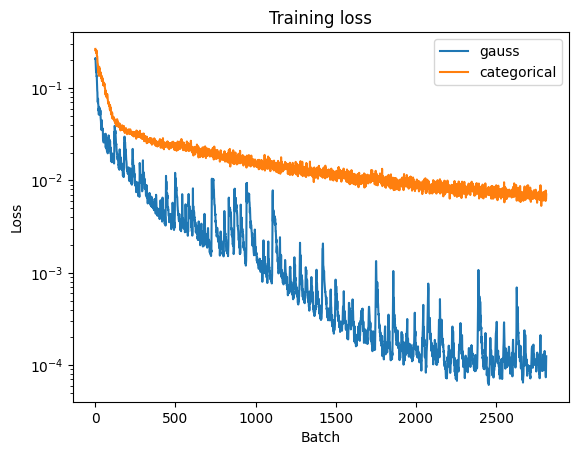

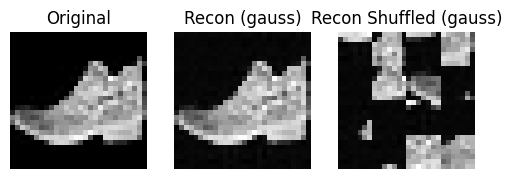

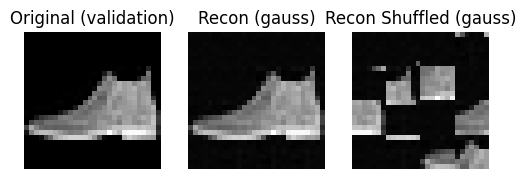

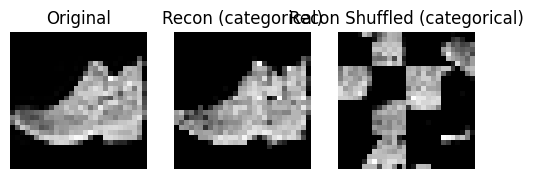

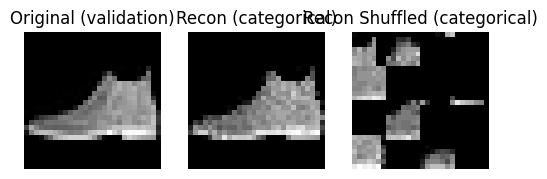

In [219]:
# Plot history loss
plt.figure()
plt.plot(loss_history_gauss, label="gauss")
plt.plot(loss_history_categorical, label="categorical")
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.yscale("log")
plt.title("Training loss")
plt.legend()
print("min loss gauss = ", min(loss_history_gauss))
print("min loss categorical = ", min(loss_history_categorical))

# Plot a recon and compare to original
images, labels = next(iter(train_loader))
model_gauss.eval()
model_categorical.eval()
recons_gauss, _, _, _ = model_gauss(images.to(device))
print("recon loss on shown training recon (gauss) = ", F.mse_loss(images[0].to(device), recons_gauss[0]).item())
print("recon loss on training recon batch (gauss) = ", F.mse_loss(images.to(device), recons_gauss).item())
recons_categorical, _, _ = model_categorical(images.to(device))
print("recon loss on shown training recon (categorical) = ", F.mse_loss(images[0].to(device), recons_categorical[0]).item())
print("recon loss on training recon batch (categorical) = ", F.mse_loss(images.to(device), recons_categorical).item())

# Shuffle patches and run a forward pass through ViT model
perm = torch.randperm(model_gauss.grid_size**2)
image_patches = patchify(images.to(device), model_gauss.patch_size)
z = model_gauss.encoder(image_patches[:, perm])
seq, _ = model_gauss.decoder(z)
recons_shuffled_gauss = unpatchify(seq, model_gauss.patch_size, model_gauss.grid_size)

perm = torch.randperm(model_categorical.grid_size**2)
image_patches = patchify(images.to(device), model_categorical.patch_size)
z = model_categorical.encoder(image_patches[:, perm])
logits, x_sample = model_categorical.decoder(z)
recons_shuffled_categorical = unpatchify(x_sample, model_categorical.patch_size, model_categorical.grid_size )


# Plot a recon and compare to original
images_val, labels_val = next(iter(test_loader))
recons_val_gauss, _, logvar, _ = model_gauss(images_val.to(device))
print("recon loss on shown validation recon (gauss) = ", F.mse_loss(images_val[0].to(device), recons_val_gauss[0]).item())
print("recon loss on validation recon batch (gauss) = ", F.mse_loss(images_val.to(device), recons_val_gauss).item())
recons_val_categorical, _, _ = model_categorical(images_val.to(device))
print("recon loss on shown validation recon (categorical) = ", F.mse_loss(images_val[0].to(device), recons_val_categorical[0]).item())
print("recon loss on validation recon batch (categorical) = ", F.mse_loss(images_val.to(device), recons_val_categorical).item())

# Shuffle patches and run a forward pass through ViT model
perm = torch.randperm(model_gauss.grid_size**2)
image_patches = patchify(images_val.to(device), model_gauss.patch_size)
z = model_gauss.encoder(image_patches[:, perm])
seq, _ = model_gauss.decoder(z)
recons_val_shuffled_gauss = unpatchify(seq, model_gauss.patch_size, model_gauss.grid_size )

perm = torch.randperm(model_categorical.grid_size**2)
image_patches = patchify(images_val.to(device), model_categorical.patch_size)
z = model_categorical.encoder(image_patches[:, perm])
logits, x_sample = model_categorical.decoder(z)
recons_val_shuffled_categorical = unpatchify(x_sample, model_categorical.patch_size, model_categorical.grid_size )


fig, ax = plt.subplots(1, 3, figsize=(6, 3))
ax[0].imshow(images[0][0].cpu().numpy(), cmap="gray")
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(recons_gauss[0][0].detach().cpu().numpy(), cmap="gray")
ax[1].set_title("Recon (gauss)")
ax[1].axis("off")

ax[2].imshow(recons_shuffled_gauss[0][0].detach().cpu().numpy(), cmap="gray")
ax[2].set_title("Recon Shuffled (gauss)")
ax[2].axis("off")

plt.show()

fig, ax = plt.subplots(1, 3, figsize=(6, 3))
ax[0].imshow(images_val[0][0].cpu().numpy(), cmap="gray")
ax[0].set_title("Original (validation)")
ax[0].axis("off")

ax[1].imshow(recons_val_gauss[0][0].detach().cpu().numpy(), cmap="gray")
ax[1].set_title("Recon (gauss)")
ax[1].axis("off")


ax[2].imshow(recons_val_shuffled_gauss[0][0].detach().cpu().numpy(), cmap="gray")
ax[2].set_title("Recon Shuffled (gauss)")
ax[2].axis("off")

plt.show()


fig, ax = plt.subplots(1, 3, figsize=(6, 3))
ax[0].imshow(images[0][0].cpu().numpy(), cmap="gray")
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(recons_categorical[0][0].detach().cpu().numpy(), cmap="gray")
ax[1].set_title("Recon (categorical)")
ax[1].axis("off")

ax[2].imshow(recons_shuffled_categorical[0][0].detach().cpu().numpy(), cmap="gray")
ax[2].set_title("Recon Shuffled (categorical)")
ax[2].axis("off")

plt.show()

fig, ax = plt.subplots(1, 3, figsize=(6, 3))
ax[0].imshow(images_val[0][0].cpu().numpy(), cmap="gray")
ax[0].set_title("Original (validation)")
ax[0].axis("off")

ax[1].imshow(recons_val_categorical[0][0].detach().cpu().numpy(), cmap="gray")
ax[1].set_title("Recon (categorical)")
ax[1].axis("off")


ax[2].imshow(recons_val_shuffled_categorical[0][0].detach().cpu().numpy(), cmap="gray")
ax[2].set_title("Recon Shuffled (categorical)")
ax[2].axis("off")

plt.show()





Here, we plot uncertainty over logits. We get the probability of each bin in the logits, and then get the "Categorical Entropy" for the probabilities. It tracks edges neatly, and shows uncertainty near them. Interestingly, it is most uncertaint inside the edges, not outside.

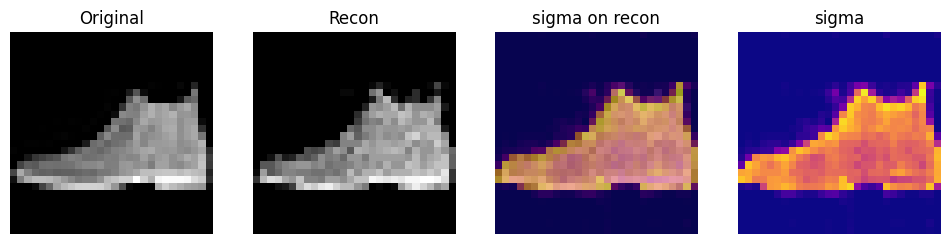

In [221]:
# Plot uncertaint map overlayed on top of reconstruction
recons_val_gauss, _, logvar, _ = model_gauss(images_val.to(device))

image_patches = patchify(images.to(device), model_categorical.patch_size)
recons_val_categorical, _, logits = model_categorical(images_val.to(device))
# Get probability of eacch logit
probs = torch.softmax(logits, dim=-1)
# get their entropy
entropy = -(probs * (probs + 1e-8).log()).sum(dim=-1)  # [B, N, P]
# normalize to [0, 1]
entropy_norm = entropy / torch.log(torch.tensor(num_bins, device=logits.device))
# confidence = probs.max(dim=-1).values   # [B, N, P]
# uncertainty = 1 - confidence

# unpatchify to overlay on the image
sigma_map = unpatchify(entropy_norm, patch_size, grid_size)


fig, ax = plt.subplots(1, 4, figsize=(12, 6))
ax[0].imshow(images_val[0][0].cpu().numpy(), cmap="gray")
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(recons_val_categorical[0][0].detach().cpu().numpy(), cmap="gray")
ax[1].set_title("Recon")
ax[1].axis("off")

ax[2].imshow(recons_val_categorical[0][0].detach().cpu().numpy(), cmap="gray")
ax[2].imshow(sigma_map[0][0].cpu().detach(), alpha=.6, cmap="plasma")  # upsamples 4×4 over the image
ax[2].set_title("sigma on recon")
ax[2].axis("off")

ax[3].imshow(sigma_map[0][0].cpu().detach(), alpha=1, cmap="plasma")  # upsamples 4×4 over the image
ax[3].set_title("sigma")
ax[3].axis("off")

plt.show()

Here, we plot distribution of possible values for a pixel in the image. We have 128 bins. You see in flat regions (background) there is a spike towards 0. Near edge of shoes, it could be either/or.

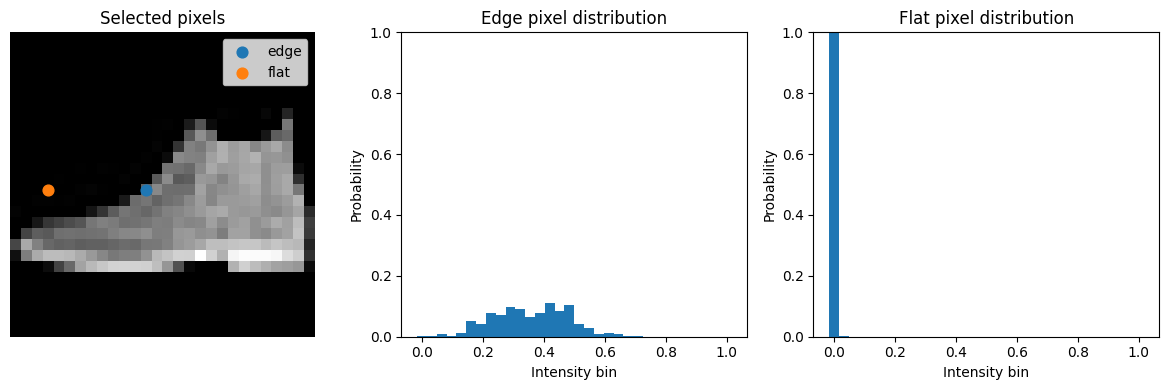

In [224]:
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F

def get_pixel_bin_probs(logits, y, x, patch_size, grid_size, b=0):
    """
    logits: [B, N, P, K]
    y, x: image pixel coordinates
    """
    K = logits.shape[-1]

    # which patch row/col?
    patch_row = y // patch_size
    patch_col = x // patch_size

    # patch index in flattened N dimension
    n = patch_row * grid_size + patch_col

    # which pixel inside the patch?
    inner_y = y % patch_size
    inner_x = x % patch_size

    p = inner_y * patch_size + inner_x

    probs = torch.softmax(logits[b, n, p], dim=-1)  # [K]

    return probs.detach().cpu()

model_categorical.eval()

with torch.no_grad():
    images, _ = next(iter(test_loader))
    images = images.to(device)

    recon, _, logits = model_categorical(images)  # [B, N, P, K]
    
edge_y, edge_x = 14, 12
flat_y, flat_x = 14, 3

edge_probs = get_pixel_bin_probs(
    logits, edge_y, edge_x,
    patch_size=patch_size,
    grid_size=grid_size
)

flat_probs = get_pixel_bin_probs(
    logits, flat_y, flat_x,
    patch_size=patch_size,
    grid_size=grid_size
)

K = logits.shape[-1]
bins = torch.arange(K)
intensities = bins / (K - 1)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

# image with selected points
ax[0].imshow(images[0, 0].detach().cpu(), cmap="gray")
ax[0].scatter([edge_x], [edge_y], s=60, label="edge")
ax[0].scatter([flat_x], [flat_y], s=60, label="flat")
ax[0].set_title("Selected pixels")
ax[0].axis("off")
ax[0].legend()

# edge pixel distribution
ax[1].bar(intensities, edge_probs, width=1/(K-1))
ax[1].set_title("Edge pixel distribution")
ax[1].set_xlabel("Intensity bin")
ax[1].set_ylabel("Probability")
ax[1].set_ylim(0, 1)

# flat pixel distribution
ax[2].bar(intensities, flat_probs, width=1/(K-1))
ax[2].set_title("Flat pixel distribution")
ax[2].set_xlabel("Intensity bin")
ax[2].set_ylabel("Probability")
ax[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

### Conclusion
All losses we used were related to one another. They all make some predicted distribution match the data distribution.

- MSE is Gaussian with a frozen uncertainty σ
- Gaussian NLL is Gaussian with a learnable uncertainty
- Cross-Entropy is uses NLL underthehood, and is used to compare probability distribution to the actual target (be it a label or a pixel)

In other words
- MSE predicts mean
- Gaussian NLL pedicts mean AND uncertainty
- Categorical Cross-Entropy predicts likelihood answer is one of the bins or class objects

Cross Entropy formula is:
CE(p, q) = H(p) + KL(p || q)
- H(p) is the true data uncertainty.
- KL(p || q) is the mismatch between the real distribution and your predicted distribution. Training reduces this part.

So minimizing entropy really means make q match p, where q is our predicted distribution.

# 3. Temporal Transformers (Causal Attn + Next-Step Prediction)

## 3.1 Causal Attention
Everything we build was bi-directional. Meaning, every image patch (a token) attended to every other patch. The job was to reconstruct the patches. In this section, we will keep the same transformer blocks, but introduce temporality in two ways:
1. Causal Masking: token `t` can only attent to tokens `<= t`. It can't peek at all tokens at once. We will mask "future" tokens.
2. Shifting Target: Instead of reconstructing the input, we will predict `x[t+1]` from `x[:t]`.

This is akin to how GPT trains. Predicting the next token given previous token (`causal`) rather than understanding the whole thing at once (`bi-directional` or `non-causal`). 

### 3.1.1 We will first make a sequential synthetic dataset

torch.Size([32, 96, 1])


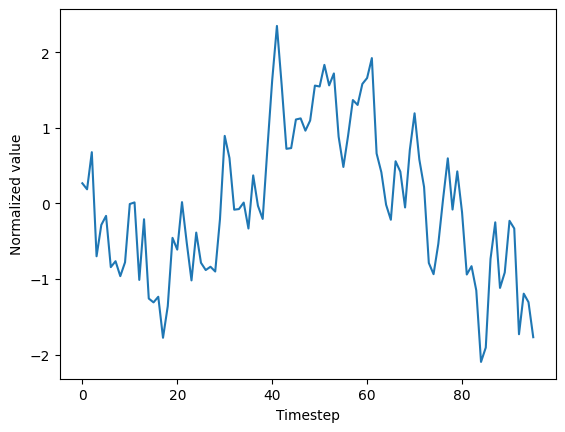

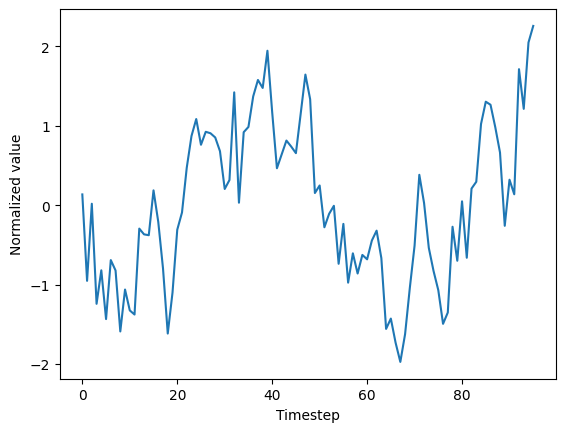

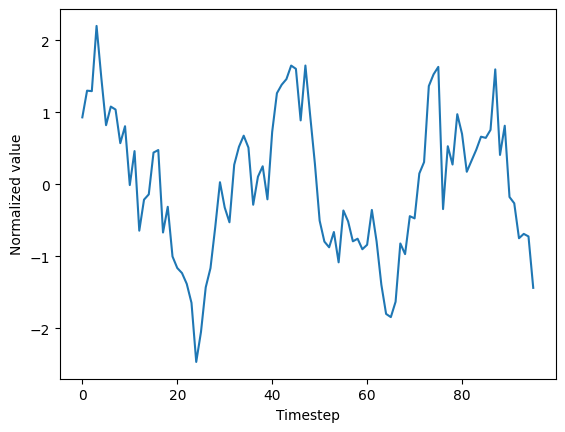

In [171]:
import math
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

class SineWaveDataset(Dataset):
    def __init__(self, num_samples=10_000, seq_len=96, noise_std=0.03):
        self.num_samples = num_samples
        self.seq_len = seq_len
        self.noise_std = noise_std
        
        # Create a linear array, divided into equal intervals, in the domain of 0 to 1
        self.t = torch.linspace(0, 1, seq_len)
        
    def __len__(self):
        return self.num_samples
    
    def __getitem__(self, idx):
        # Generate random frequencies uniformly between defined domains
        f1 = torch.empty(1).uniform_(1.0, 4.0) # a random number between 1 and 4
        f2 = torch.empty(1).uniform_(4.0, 10.0) # a random number between 4 and 10
        f3 = torch.empty(1).uniform_(10.0, 20.0) # a random number between 4 and 10
        
        # Generate random phases. this shift the wave randomly left or right. 
        # That way, every sample doesn't start from the same point. 
        # Without phase, all waves start at sin(0) = 0.
        phase1 = torch.empty(1).uniform_(0, 2 * math.pi)
        phase2 = torch.empty(1).uniform_(0, 2 * math.pi)
        phase3 = torch.empty(1).uniform_(0, 2 * math.pi)
        
        # Construct synthetic wave
        x = torch.sin(2 * math.pi * f1 * self.t + phase1) + 0.5 * torch.sin(2 * math.pi * f2 * self.t + phase2)  + 0.25 * torch.sin(2 * math.pi * f3 * self.t + phase3) 
        # add noise to wave
        x = x + self.noise_std * torch.randn_like(x) 
        
        # Normalize each sequence independently
        x = (x - x.mean()) / (x.std() + 1e-6)
        
        return x.unsqueeze(-1) # (T, 1)
    

# Inspect a batch and plot a few sequences to verify
dataset = SineWaveDataset(num_samples=10000, seq_len=96, noise_std=0.3)
# split into training and testing dataset
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size], generator=torch.Generator().manual_seed(42))
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(dataset, batch_size=32, shuffle=False)

x = next(iter(train_loader))
print(x.shape)
        
for i in range(3):
    plt.figure()
    plt.plot(x[i, :, 0])
    plt.xlabel("Timestep")
    plt.ylabel("Normalized value")
    plt.show()
    

### 3.1.2 Transformer block with Causal Attn
This is exactly same transformer block (Multihead attention with RoPE). Only difference is `F.scaled_dot_product_attention` has `is_causal=True` rather than `False`.

In [235]:
class MHA_RoPE(nn.Module):
    def __init__(self, dim: int, n_heads: int, is_causal: bool, use_rope: str | None = "1d"):
        super().__init__()
        self.head_dim = dim // n_heads
        self.n_heads = n_heads
        self.use_rope = use_rope
        self.is_causal = is_causal
        self.last_attention = None
        self.proj = nn.Linear(dim, 3 * self.head_dim * n_heads, bias=False)
        
        # The last layer that fuses multiple attention heads into a single layer
        self.to_out = nn.Linear(self.head_dim * n_heads, dim, bias=False)
        
        # If a model was trained with RoPE, it should use RoPE even during inference
        if use_rope is not None:
            # Registering empty cache for rope angles
            # this is similar to saying self.rope_angles = build_cache(), but they now show in model.state_dict(). 
            # persistant = False means the params wont be saved when saving model
            # buffer cannot be optimized unlike nn.Parameter.
            
            if use_rope == "2d":
                self.register_buffer("rope_angles_y", None, persistent=False)
                self.register_buffer("rope_angles_x", None, persistent=False)

            else:
                self.register_buffer("rope_angles", None, persistent=False)         

        
    def forward(self, seq, get_attn_matrix=False):
        """
        Args:
            seq (B, N, dim)
            
        Returns:
            out: (B, N, dim)
            attention: (B, n_heads, N, dim)
        """
        B, N, dim = seq.size()
        
        # project to Q, K and V
        qkv = self.proj(seq)
        # Rearrange to move head outside to perform attention calucation PER head        
        qkv = einops.rearrange(qkv, "b n (h d) -> b h n d", h = self.n_heads)
        # Divide d into 3 chunks d/3 for each query, key and value
        q, k, v = qkv.chunk(3, dim=-1)
                        
        if self.use_rope is not None and self.use_rope=="2d":
            # Build rope angle matrix if not build or if sequence length increased
            if (self.rope_angles_y is None) or (self.rope_angles_y.shape[0]) < N:
                grid_size = int(N**0.5)
                assert grid_size * grid_size == N # todo change to non-square grid size rope
                self.rope_angles_y, self.rope_angles_x = build_rope_2d_cache(grid_size, self.head_dim, seq.device)
                
            q = apply_rope_2d(q, (self.rope_angles_y, self.rope_angles_x))
            k = apply_rope_2d(k, (self.rope_angles_y, self.rope_angles_x))
        
        elif self.use_rope is not None:
            # Build rope angle matrix if not build or if sequence length increased
            if (self.rope_angles is None) or (self.rope_angles.shape[0]) < N:
                self.rope_angles = build_rope_1d_cache(N, self.head_dim, seq.device)
                
            q = apply_rope_1d(q, self.rope_angles)
            k = apply_rope_1d(k, self.rope_angles)            
               
        self.last_attention = None

        if get_attn_matrix:
            # Dot product of Queries and Keys
            score_matrix = einops.einsum(q, k, "... n1 d, ... n2 d -> ... n1 n2") # contracted dimension much share same var name in einops (here it is 'd')
            
            # # scale by head size
            score_matrix = score_matrix / (self.head_dim**0.5)
            
            if self.is_causal:
                causal_mask = torch.triu(torch.ones(N, N, device=seq.device, dtype=torch.bool), diagonal=1)
                score_matrix = score_matrix.masked_fill(causal_mask, float("-inf"))
            
            # # Applying softmax to the score matrix
            attention = torch.softmax(score_matrix, dim=-1)
            
            self.last_attention = attention.detach()
            
            # # Weighting attention by the value
            # out = attention @ v
        
        # Torch's flash attention formula, same result just faster. Also commonly known as "SDPA"
        # is_causal set to True for causal attention
        out = F.scaled_dot_product_attention(q, k, v, is_causal=self.is_causal) # (B, num_heads, N, head_dim)
        
        # Move heads back to dim
        out = einops.rearrange(out, "b h n d -> b n (h d)")
        
        # Fuse multi-heads int a linear layer
        out = self.to_out(out)
        
        return out

# Example
mha = MHA_RoPE(dim=768, n_heads=12, is_causal=True).to(device)

x1 = torch.randn(2, 64, 768).to(device)
y1 = mha(x1)

x2 = torch.randn(2, 144, 768).to(device)
y2 = mha(x2)

x3 = torch.randn(2, 196, 768).to(device)
y3= mha(x3)


class AttnBlock(nn.Module):
    def __init__(self, dim: int, n_heads: int, is_causal: bool, use_rope: str | None = "1d", attn_multiple: int = 4):
        super().__init__()
        self.attention = MHA_RoPE(dim, n_heads, use_rope=use_rope, is_causal=is_causal)
        self.layer_norm1 = nn.LayerNorm(dim)
        self.layer_norm2 = nn.LayerNorm(dim)
        self.ff = nn.Sequential(
            nn.Linear(dim, attn_multiple * dim),
            nn.GELU(),
            nn.Linear(attn_multiple * dim, dim)
        )        
                    
    def forward(self, x, get_attn_matrix=False):
        # attending to tokens across patches with a residual
        out = self.attention(self.layer_norm1(x), get_attn_matrix=get_attn_matrix)
        x = x + out
        
        # channel mixing per token - a "scratch space" to make sense of the tokens we attended to
        out = self.ff(self.layer_norm2(x))
        x = x + out
        
        return x
    
# To get the attention matrix of a block, we can do the following
# with torch.no_grad():
# h = model.encoder(x)

# block = model.attn_blocks[0]
# _ = block.attention(block.layer_norm1(h),  get_attn_matrix=True)
# attention_matrix = model.attn_blocks[0].attention.last_attention

Creating a simple auto-regressive predictor with attention blocks

In [236]:
class AutoRegressivePredictor(nn.Module):
    def __init__(self, dim=256, n_head=6, attn_blocks=2):
        super().__init__()
        self.encoder = nn.Linear(1, dim)
        self.attn_blocks = nn.Sequential(*[AttnBlock(dim, n_head, is_causal=True, use_rope="1d") for item in range(attn_blocks)])
        self.decoder = nn.Linear(dim, 1)
    
    def forward(self, x):
        x = self.encoder(x)
        x = self.attn_blocks(x)
        x = self.decoder(x)
        return x

### 3.1. Training loop
Now we train and plot results

In [237]:
# parameters
epochs = 5
dim = 256
n_heads = 6
attn_blocks = 2
learning_rate = 1e-3

# defining model and optimizer
model = AutoRegressivePredictor(dim, n_heads, attn_blocks).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

loss_history = []
loss_history_val = []

# Training
for epoch in range(epochs):
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
    for data in pbar:
        x = data[:, :-1].to(device)
        y = data[:, 1:].to(device)
        y_pred = model(x)
        
        # get loss
        loss = F.mse_loss(y_pred, y)
        
        # optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        loss_history.append(loss.item())
        
        # show live loss
        pbar.set_postfix(loss=loss.item())
        
        
    # get validation data point
    model.eval()
    val_losses = []
    with torch.no_grad():
        for data in test_loader:
            x = data[:, :-1].to(device)
            y = data[:, 1:].to(device)

            y_pred = model(x)
            val_loss = F.mse_loss(y_pred, y)
            val_losses.append(val_loss.item())

    mean_val_loss = sum(val_losses) / len(val_losses)
    loss_history_val.append(mean_val_loss)  
        
    
    

Epoch 1/5:   0%|          | 0/313 [00:00<?, ?it/s]

KeyboardInterrupt: 

Plot results

In [218]:
import numpy as np
import matplotlib.pyplot as plt

def plot_loss(loss_history, loss_history_val):
    plt.figure(figsize=(8, 4))
    
    # plot training loss history
    plt.plot(range(len(loss_history)), loss_history, label="train loss")
    
    # spread test losses across same training range if different
    val_steps = [i * (len(loss_history) - 1) / max(len(loss_history_val) - 1, 1) for i in range(len(loss_history_val))]
    
    # plot validation loss history on same plot
    plt.plot(val_steps, loss_history_val, label="validation loss")
    
    plt.xlabel("Training step")
    plt.ylabel("Loss")
    plt.ylim((0,np.max(loss_history_val)*2))
    
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
    
    
def plot_rollout(model, batch, device="cuda", sample_idx=0):
    model.eval()
    x = batch[:, :-1].to(device) # (B, T, 1)
    y = batch[:, 1:].cpu() # (B, T, 1)
    
    with torch.no_grad():
        y_pred = model(x).cpu()
        
    plt.figure(figsize=(10, 4))
    plt.plot(y[sample_idx], label="actual next value (target)")
    plt.plot(y_pred[sample_idx], label="predicted next value (prediction)")
    plt.xlabel("Timestep")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
    
    
def plot_autoregressive_rollout(model, batch, device="cuda", sample_idx=0, seed_samples=10):
    """
    Seed model with few steps, and autoregressively predict next token without
    giving transformer full picture
    """
    model.eval()
    seq_len = batch.shape[1]

    x = batch[:, :seed_samples].to(device) # (B, T, 1)
    y = batch[:, 1:].cpu() # (B, T, 1)
    
    with torch.no_grad():
        while x.shape[1] < seq_len:
            y_pred = model(x)
            next_token = y_pred[:, -1:, :]
            x = torch.cat([x, next_token], dim=1)

        y_pred = x.cpu()        
        
    plt.figure(figsize=(10, 4))
    plt.plot(y[sample_idx], label="actual next value (target)")
    plt.plot(y_pred[sample_idx], label="predicted next value (prediction)")
    plt.xlabel("Timestep")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
        
        
        
def plot_causal_attn_map(model, batch, device="cuda", sample_idx=0):
    model.eval()

    x = batch[:sample_idx + 1, :-1].to(device)

    with torch.no_grad():

        embedded = model.encoder(x)
        block = model.attn_blocks[0]
        _= block.attention(block.layer_norm1(embedded),  get_attn_matrix=True)
        attention_matrix = model.attn_blocks[0].attention.last_attention

    attention_matrix = attention_matrix[0, 0].cpu()  # sample 0, head 0

    plt.figure(figsize=(7, 6))
    plt.imshow(attention_matrix, aspect="auto", origin="upper")
    plt.colorbar(label="Attention weight")
    plt.xlabel("Key timestep")
    plt.ylabel("Query timestep")
    plt.title("Causal attention — layer 0, head 0")
    plt.show()



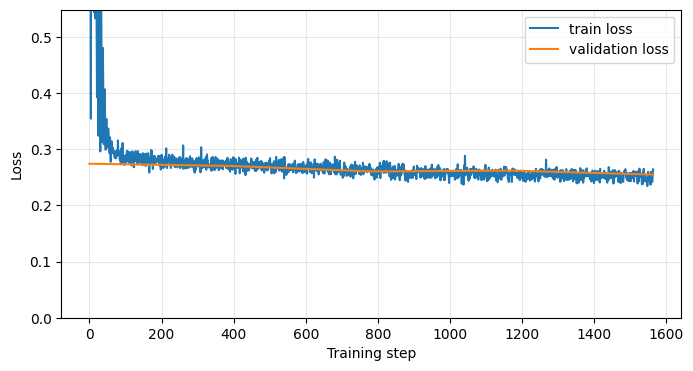

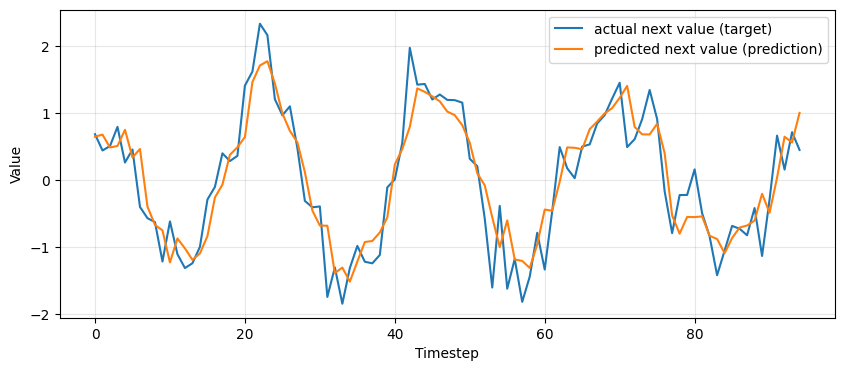

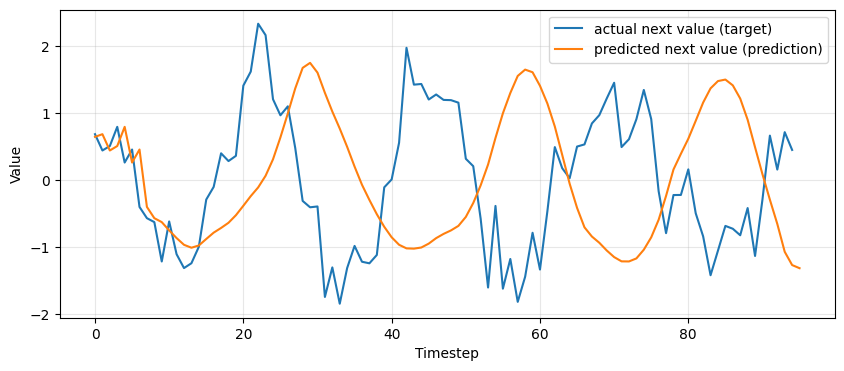

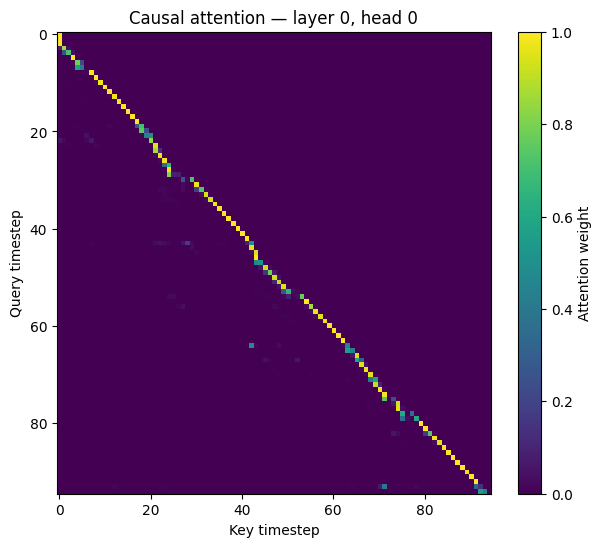

In [229]:
plot_loss(loss_history, loss_history_val)

# plot teach-forced prediction vs actual wave form
batch = next(iter(test_loader))
plot_rollout(model, batch, device=device)
plot_autoregressive_rollout(model, batch, device=device, seed_samples=10)
plot_causal_attn_map(model, batch, device=device)


### 3.1.4 Finetuning with DAgger Memory Training (DMT)
This finetuning method was introduced in this reseach paper: https://arxiv.org/pdf/2606.06479 as a way to tune an encoder after training the model for auto-regressive rollouts.

The idea behind it is that teacher-forced encoders are trained on to predict next token from the ground truth at each time step. When we roll-out autoregressively during inference (without ground the model in the ground truth steps), the error compounds with each step of the rollout trajectory. That is why this step allows us to finetune model to correct the drif via on-policy imitation learning.

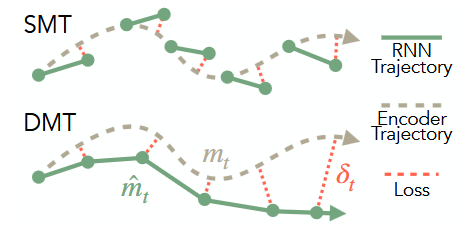
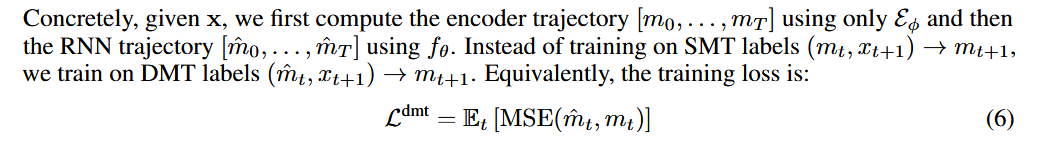

In [223]:
# Keep a copy of the teacher-forced model for comparison
import copy
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm
tf_model = copy.deepcopy(model).eval()

In [225]:
import copy
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

dmt_model = copy.deepcopy(model).train()

for param in dmt_model.encoder.parameters():
    param.requires_grad = False

for param in dmt_model.decoder.parameters():
    param.requires_grad = False

for param in dmt_model.attn_blocks.parameters():
    param.requires_grad = True
    
dmt_optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, dmt_model.parameters()),
    lr=1e-4
)

def autoregressive_rollout(model, sequence, seed_samples=10):
    """
    sequence: (B, T, 1)

    Returns:
        generated: (B, T, 1)

    The first seed_samples values are real.
    All later values are generated autoregressively.
    """
    T = sequence.shape[1]

    generated = sequence[:, :seed_samples].clone()

    while generated.shape[1] < T:
        predictions = model(generated)

        # Prediction after the final generated timestep
        next_value = predictions[:, -1:, :]

        generated = torch.cat([generated, next_value], dim=1)

    return generated

dmt_epochs = 1
seed_samples = 30

dmt_loss_history = []
dmt_val_history = []

for epoch in range(dmt_epochs):
    dmt_model.train()

    pbar = tqdm(
        train_loader,
        desc=f"DMT {epoch + 1}/{dmt_epochs}",
        leave=False
    )

    for sequence in pbar:
        sequence = sequence.to(device)

        generated = autoregressive_rollout(dmt_model, sequence, seed_samples=seed_samples)

        # Only penalize the autoregressively generated portion
        rollout_loss = F.mse_loss(
            generated[:, seed_samples:],
            sequence[:, seed_samples:]
        )        
        
        tf_pred = model(sequence[:, :-1])
        tf_loss = F.mse_loss(tf_pred, sequence[:, 1:])
        
        loss = rollout_loss + 0.1 * tf_loss

        dmt_optimizer.zero_grad()
        loss.backward()

        # Useful because the graph spans the whole rollout
        torch.nn.utils.clip_grad_norm_(
            filter(lambda p: p.requires_grad, dmt_model.parameters()),
            max_norm=1.0
        )

        dmt_optimizer.step()

        dmt_loss_history.append(loss.item())
        pbar.set_postfix(rollout_loss=loss.item())

    # Validation rollout loss
    dmt_model.eval()
    val_losses = []

    with torch.no_grad():
        for sequence in test_loader:
            sequence = sequence.to(device)

            generated = autoregressive_rollout(
                dmt_model,
                sequence,
                seed_samples=seed_samples
            )

            rollout_loss = F.mse_loss(
                generated[:, seed_samples:],
                sequence[:, seed_samples:]
            )
            
            tf_pred = model(sequence[:, :-1])
            tf_loss = F.mse_loss(tf_pred, sequence[:, 1:])
            
            loss = rollout_loss + 0.1 * tf_loss

            val_losses.append(loss.item())

    mean_val_loss = sum(val_losses) / len(val_losses)
    dmt_val_history.append(mean_val_loss)

    print(
        f"Epoch {epoch + 1}: "
        f"validation rollout MSE = {mean_val_loss:.6f}"
    )
    
    
import matplotlib.pyplot as plt


DMT 1/1:   0%|          | 0/313 [00:00<?, ?it/s]

KeyboardInterrupt: 

predict-mean baseline MSE (region variance) = 0.9874
TF-only rollout MSE = 1.1545  (117% of baseline)
DMT     rollout MSE = 0.9485  (96% of baseline)


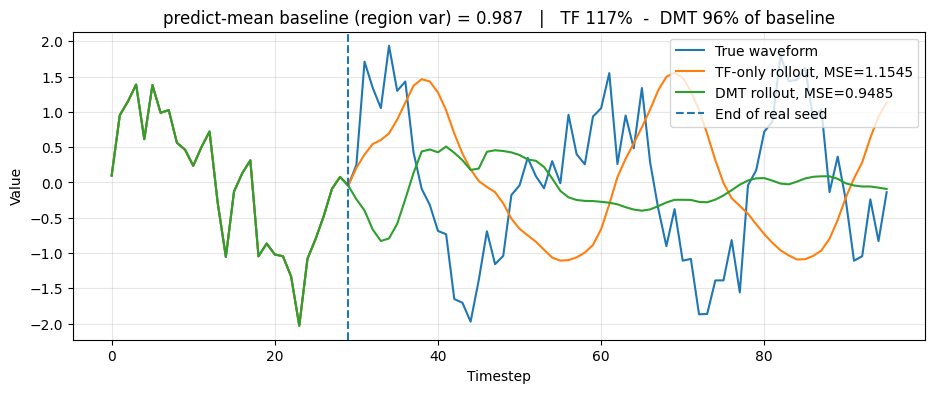

In [227]:

def compare_rollouts(
    tf_model,
    dmt_model,
    batch,
    device="cuda",
    sample_idx=0,
    seed_samples=10
):
    tf_model.eval()
    dmt_model.eval()

    sequence = batch.to(device)

    with torch.no_grad():
        tf_rollout = autoregressive_rollout(tf_model, sequence, seed_samples)
        dmt_rollout = autoregressive_rollout(dmt_model, sequence, seed_samples)

    actual = sequence[sample_idx, :, 0].cpu()
    tf_pred = tf_rollout[sample_idx, :, 0].cpu()
    dmt_pred = dmt_rollout[sample_idx, :, 0].cpu()

    # Score only the autoregressively generated tail
    tf_mse = F.mse_loss(tf_rollout[:, seed_samples:], sequence[:, seed_samples:]).item()
    dmt_mse = F.mse_loss(dmt_rollout[:, seed_samples:], sequence[:, seed_samples:]).item()

    # "Predict the mean" baseline = variance of the SCORED region.
    # NOT 1.0 - the std=1 normalization is over the full sequence, but we only score the
    # tail, whose variance differs. This is the honest "did we beat predicting the mean" line.
    baseline = sequence[:, seed_samples:].var().item()

    print(f"predict-mean baseline MSE (region variance) = {baseline:.4f}")
    print(f"TF-only rollout MSE = {tf_mse:.4f}  ({tf_mse / baseline:.0%} of baseline)")
    print(f"DMT     rollout MSE = {dmt_mse:.4f}  ({dmt_mse / baseline:.0%} of baseline)")

    plt.figure(figsize=(11, 4))
    plt.plot(actual, label="True waveform")
    plt.plot(tf_pred, label=f"TF-only rollout, MSE={tf_mse:.4f}")
    plt.plot(dmt_pred, label=f"DMT rollout, MSE={dmt_mse:.4f}")
    plt.axvline(seed_samples - 1, linestyle="--", label="End of real seed")
    plt.title(
        f"predict-mean baseline (region var) = {baseline:.3f}   |   "
        f"TF {tf_mse / baseline:.0%}  -  DMT {dmt_mse / baseline:.0%} of baseline"
    )
    plt.xlabel("Timestep")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()



batch = next(iter(test_loader))
# plot_loss(dmt_loss_history, dmt_val_history)

compare_rollouts(
    tf_model=tf_model,
    dmt_model=dmt_model,
    batch=batch,
    device=device,
    seed_samples=seed_samples
)
